# ROC Curve Visualizations
Central notebook for all ROC curve analysis of the C2 classifier.
Run cells top-to-bottom; each section after **Setup** can be re-run independently.

---
## 1. Setup — Imports, Config & Helpers

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import sys

In [2]:
# ── Config ────────────────────────────────────────────────────────────────────
DISEASE   = 'effusion'   # 'effusion' | 'pneumothorax' | 'cardiomegaly'
CF_COUNT  = 16
ROC_PATH  = f'/zhome/d0/a/221493/thesis/results/C2_custom_corrected/{DISEASE}/cv_results_unmatched/cf_{CF_COUNT}/cv_detailed.json'
OUTPUT_DIR = 'images/'
print(f"Loading ROC data from: {ROC_PATH}")

# Import color palette from plot_config
sys.path.insert(0, '/zhome/d0/a/221493/thesis/code')
from plot_config import PLOT_COLORS, PLOT_LS, PLOT_LW

COLORS     = PLOT_COLORS
LINESTYLES = PLOT_LS
LINEWIDTHS = PLOT_LW

MODELS_TO_PLOT = ['LR', 'RF', 'MLP']
CONFIGS_TO_SHOW = {
    'LR':  ['B1', 'B2', 'B3', 'B4', 'B5', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6'],
    'RF':  ['B1', 'B2', 'B3', 'B4', 'B5', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6'],
    'MLP': ['B1', 'B2', 'B3', 'B4', 'B5', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6'],
}
MCF_CONFIGS_TO_SHOW = {
    'LR':  ['MCF1', 'MCF2', 'MCF3', 'MCF4', 'MCF5'],
    'RF':  ['MCF1', 'MCF2', 'MCF3', 'MCF4', 'MCF5'],
    'MLP': ['MCF1', 'MCF2', 'MCF3', 'MCF4', 'MCF5'],
}

# Baseline (B1–B5): no delta features
# B1: prob only  B2: attrs only  B3: emb only  B4: prob+attrs  B5: prob+emb
# Multi-modal (M1–M6): include delta features
# M1: ΔA only  M2: prob+ΔA  M3: prob+ΔA+attrs  M4: prob+ΔA+emb
# M5: prob+ΔA+attrs+emb  M6: prob+ΔA+attrs+CF-prob
# CF-enriched (MCF1–MCF5): include raw CF features
# MCF1: prob+CF-prob  MCF2: prob+CF-prob+attrs+CF-attrs
# MCF3: MCF2+ΔA  MCF4: MCF3+emb+CF-emb  MCF5: MCF4+Δemb

LABELS = {
    'B1': 'B1 (Prob only)',        'B2': 'B2 (Attrs only)',
    'B3': 'B3 (Embeddings only)',  'B4': 'B4 (Prob+Attrs)',
    'B5': 'B5 (Prob+Emb)',         'M1': 'M1 (ΔA only)',
    'M2': 'M2 (Prob+ΔA)',          'M3': 'M3 (Prob+ΔA+Attrs)',
    'M4': 'M4 (Prob+ΔA+Emb)',      'M5': 'M5 (Prob+ΔA+Attrs+Emb)',
    'M6': 'M6 (Prob+ΔA+Attrs+CF)',
    'MCF1': 'MCF1 (Prob+CF-Prob)',
    'MCF2': 'MCF2 (Prob+CF-Prob+Attrs+CF-Attrs)',
    'MCF3': 'MCF3 (MCF2+ΔA)',
    'MCF4': 'MCF4 (MCF3+Emb+CF-Emb)',
    'MCF5': 'MCF5 (MCF4+ΔEmb)',
}
MODEL_NAMES = {'LR': 'Logistic Regression', 'RF': 'Random Forest', 'MLP': 'Multilayer Perceptron'}

Loading ROC data from: /zhome/d0/a/221493/thesis/results/C2_custom_corrected/effusion/cv_results_unmatched/cf_16/cv_detailed.json


In [3]:
# ── Shared helpers ────────────────────────────────────────────────────────────
common_fpr = np.linspace(0, 1, 300)

def load_roc(data, model, config):
    """Average ROC across CV folds from a full results dict (data[model][config])."""
    folds = data[model][config]
    tprs = [np.interp(common_fpr, f['fpr'], f['tpr']) for f in folds]
    return {
        'fpr': common_fpr,
        'tpr': np.mean(tprs, axis=0),
        'std': np.std(tprs, axis=0),
        'auc': np.mean([f['auc'] for f in folds]),
        'auc_std': np.std([f['auc'] for f in folds]),
    }

def load_roc_folds(folds):
    """Average ROC across CV folds from a flat list of fold dicts."""
    tprs = [np.interp(common_fpr, f['fpr'], f['tpr']) for f in folds]
    return {
        'fpr': common_fpr,
        'tpr': np.mean(tprs, axis=0),
        'std': np.std(tprs, axis=0),
        'auc': np.mean([f['auc'] for f in folds]),
        'auc_std': np.std([f['auc'] for f in folds]),
    }

## 2. All Configs ROC — per Model (LR / RF / MLP)

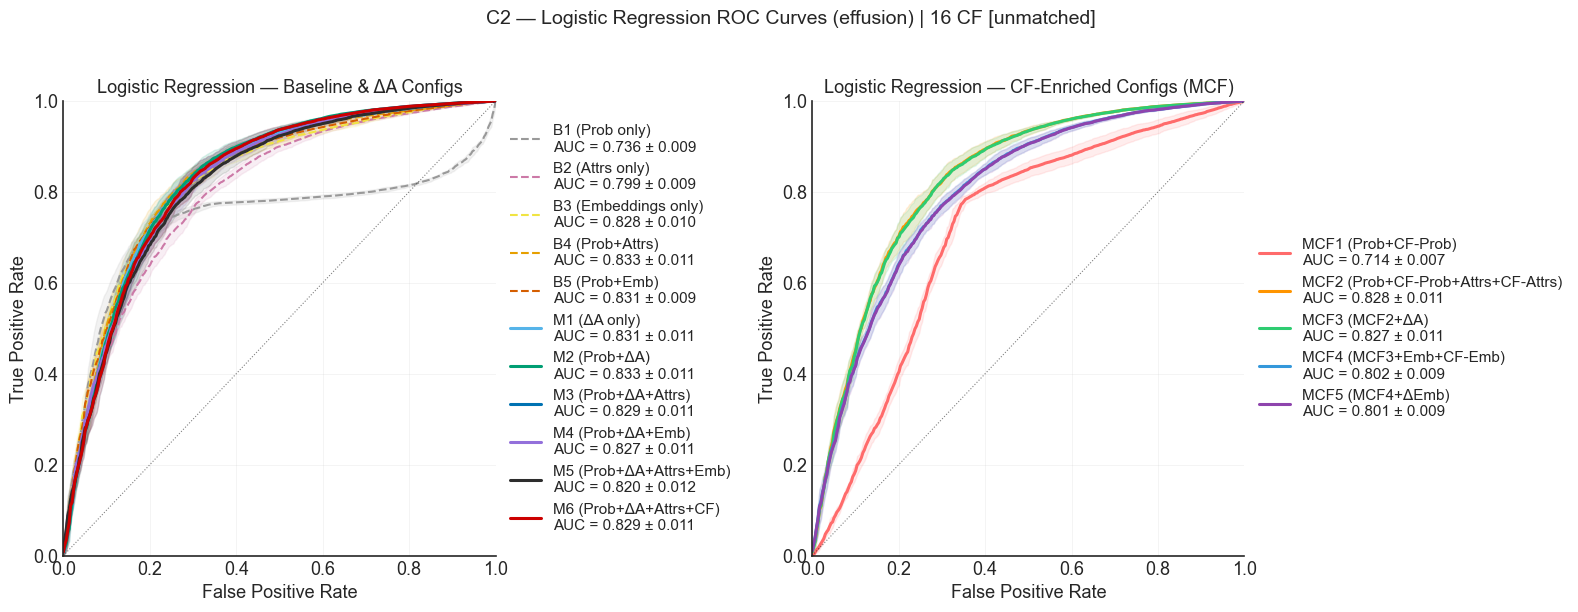

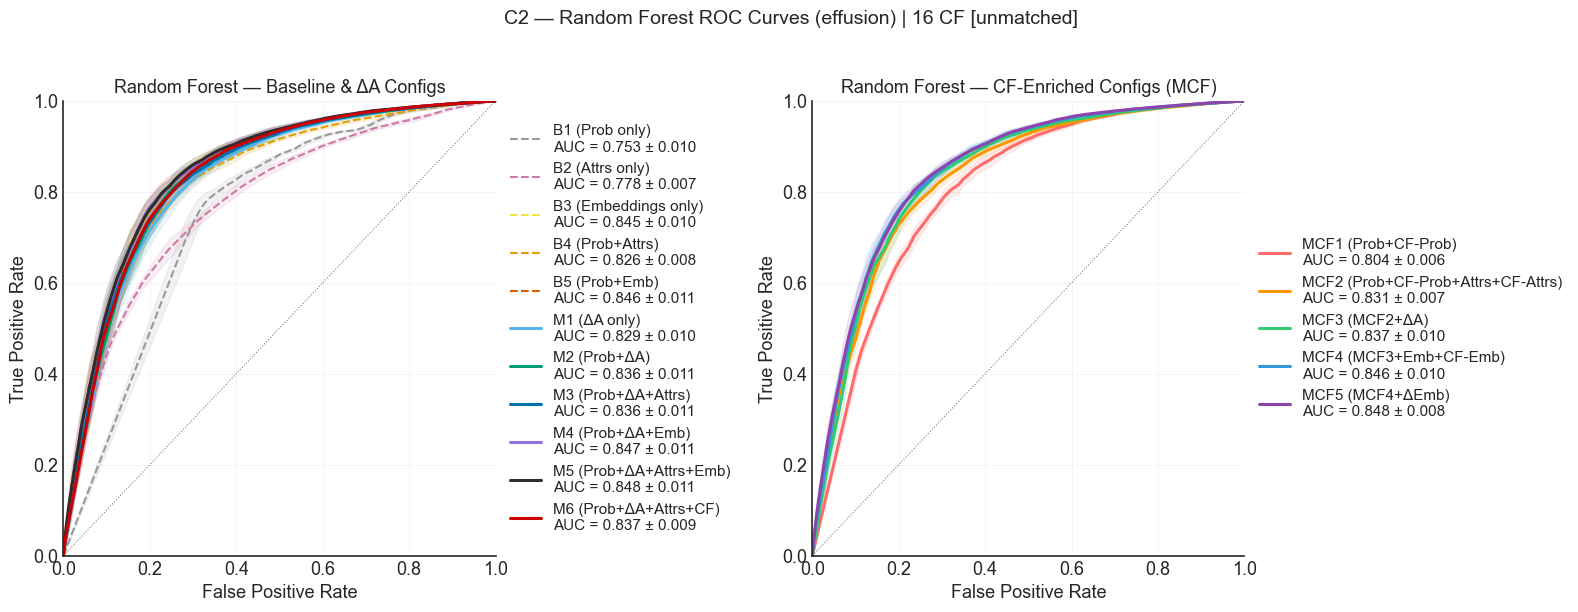

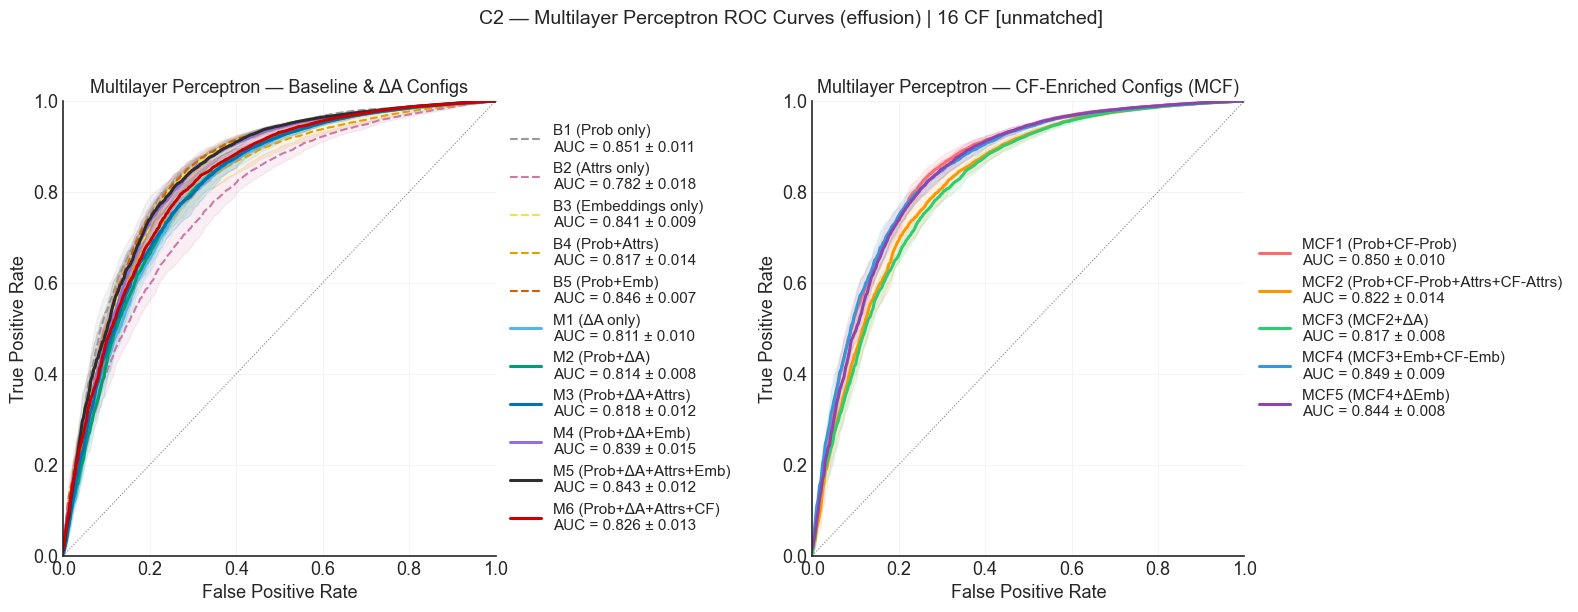

In [34]:
# ── Load & average ROC across folds ───────────────────────────────────────────
with open(ROC_PATH) as f:
    raw = json.load(f)

roc_data = {}
mcf_roc_data = {}
for model in MODELS_TO_PLOT:
    roc_data[model] = {}
    for config in CONFIGS_TO_SHOW[model]:
        roc_data[model][config] = load_roc(raw, model, config)
    mcf_roc_data[model] = {}
    for config in MCF_CONFIGS_TO_SHOW[model]:
        mcf_roc_data[model][config] = load_roc(raw, model, config)

# ── Plot — one figure per model, two subplots: B*/M* (left) and MCF* (right) ──
plt.style.use('seaborn-v0_8-white')
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 13,
    'axes.titlesize': 13, 'axes.labelsize': 13,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'legend.fontsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 1.2, 'grid.alpha': 0.3,
    'grid.linewidth': 0.6, 'lines.linewidth': 1.8,
})

os.makedirs(OUTPUT_DIR, exist_ok=True)

for model in MODELS_TO_PLOT:
    fig, (ax_bm, ax_mcf) = plt.subplots(1, 2, figsize=(16, 6))

    # ── Left subplot: B* and M* configs ───────────────────────────────────────
    for config in CONFIGS_TO_SHOW[model]:
        d = roc_data[model][config]
        ax_bm.plot(d['fpr'], d['tpr'],
                   color=COLORS[config], lw=LINEWIDTHS[config], ls=LINESTYLES[config],
                   label=f"{LABELS[config]}\nAUC = {d['auc']:.3f} ± {d['auc_std']:.3f}")
        ax_bm.fill_between(d['fpr'], d['tpr'] - d['std'], d['tpr'] + d['std'],
                           color=COLORS[config], alpha=0.12)
    ax_bm.plot([0, 1], [0, 1], 'k:', lw=0.8, alpha=0.5)
    ax_bm.set_xlabel('False Positive Rate')
    ax_bm.set_ylabel('True Positive Rate')
    ax_bm.set_title(f'{MODEL_NAMES[model]} — Baseline & ΔA Configs', size=13)
    ax_bm.set_xlim(0, 1); ax_bm.set_ylim(0, 1)
    ax_bm.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
    ax_bm.grid(alpha=0.30, linewidth=0.5)

    # ── Right subplot: MCF* configs ────────────────────────────────────────────
    for config in MCF_CONFIGS_TO_SHOW[model]:
        d = mcf_roc_data[model][config]
        ax_mcf.plot(d['fpr'], d['tpr'],
                    color=COLORS[config], lw=LINEWIDTHS[config], ls=LINESTYLES[config],
                    label=f"{LABELS[config]}\nAUC = {d['auc']:.3f} ± {d['auc_std']:.3f}")
        ax_mcf.fill_between(d['fpr'], d['tpr'] - d['std'], d['tpr'] + d['std'],
                            color=COLORS[config], alpha=0.12)
    ax_mcf.plot([0, 1], [0, 1], 'k:', lw=0.8, alpha=0.5)
    ax_mcf.set_xlabel('False Positive Rate')
    ax_mcf.set_ylabel('True Positive Rate')
    ax_mcf.set_title(f'{MODEL_NAMES[model]} — CF-Enriched Configs (MCF)', size=13)
    ax_mcf.set_xlim(0, 1); ax_mcf.set_ylim(0, 1)
    ax_mcf.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
    ax_mcf.grid(alpha=0.30, linewidth=0.5)

    fig.suptitle(
        f'C2 — {MODEL_NAMES[model]} ROC Curves ({DISEASE}) | {CF_COUNT} CF [unmatched]',
        size=14, y=1.02
    )
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'roc_{model.lower()}_{CF_COUNT}.png'), dpi=150, bbox_inches='tight')
    plt.show()

In [35]:
# ── Summary table: AUC ± std across all configs and model types ───────────────
all_configs = CONFIGS_TO_SHOW['LR'] + MCF_CONFIGS_TO_SHOW['LR']

rows = []
for config in all_configs:
    row = {'Config': config, 'Description': LABELS[config]}
    for model in MODELS_TO_PLOT:
        src = roc_data[model] if config in roc_data[model] else mcf_roc_data[model]
        d = src[config]
        row[MODEL_NAMES[model]] = f"{d['auc']:.3f} ± {d['auc_std']:.3f}"
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index('Config')
print(f"\nAUC Summary — {DISEASE} | CF={CF_COUNT} [unmatched]\n{'='*80}")
print(summary_df.to_string())


AUC Summary — effusion | CF=16 [unmatched]
                               Description Logistic Regression  Random Forest Multilayer Perceptron
Config                                                                                             
B1                          B1 (Prob only)       0.736 ± 0.009  0.753 ± 0.010         0.851 ± 0.011
B2                         B2 (Attrs only)       0.799 ± 0.009  0.778 ± 0.007         0.782 ± 0.018
B3                    B3 (Embeddings only)       0.828 ± 0.010  0.845 ± 0.010         0.841 ± 0.009
B4                         B4 (Prob+Attrs)       0.833 ± 0.011  0.826 ± 0.008         0.817 ± 0.014
B5                           B5 (Prob+Emb)       0.831 ± 0.009  0.846 ± 0.011         0.846 ± 0.007
M1                            M1 (ΔA only)       0.831 ± 0.011  0.829 ± 0.010         0.811 ± 0.010
M2                            M2 (Prob+ΔA)       0.833 ± 0.011  0.836 ± 0.011         0.814 ± 0.008
M3                      M3 (Prob+ΔA+Attrs)       0.829 ±

## 3. CF Value Ablation — B1 → B4 → M3 (CF=1 vs CF=16)

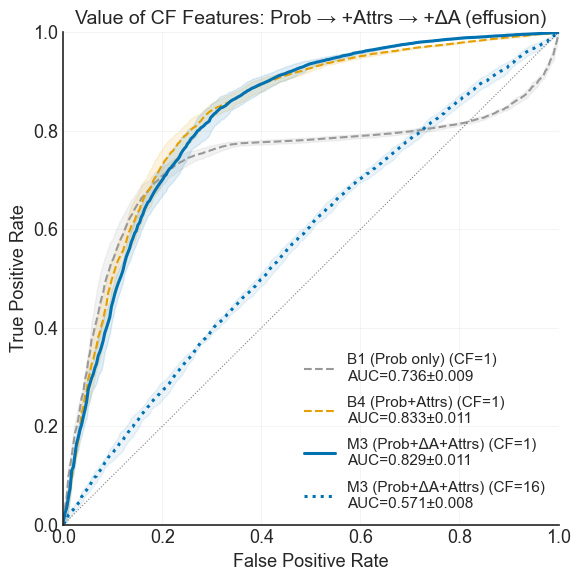

In [36]:
# ── Load configs from cf=16 for comparison ─────────────────────────────────────
with open(f'/zhome/d0/a/221493/thesis/results/C2_custom_corrected/{DISEASE}/cv_results/cf_16/cv_detailed.json') as f:
    raw_cf16 = json.load(f)

folds_cf16 = raw_cf16['LR']['M3']
mean_auc_cf16 = np.mean([f['auc'] for f in folds_cf16])
tprs_cf16 = [np.interp(common_fpr, f['fpr'], f['tpr']) for f in folds_cf16]
m3_cf16 = {
    'fpr': common_fpr,
    'tpr': np.mean(tprs_cf16, axis=0),
    'std': np.std(tprs_cf16, axis=0),
    'auc': mean_auc_cf16,
    'auc_std': np.std([f['auc'] for f in folds_cf16])
}

fig, ax = plt.subplots(figsize=(6, 6))
# B1 → B4 → M3: shows incremental value of attrs, then CF-derived delta features
configs = ['B1', 'B4', 'M3']

for config in configs:
    d = roc_data['LR'][config]
    ax.plot(
        d['fpr'], d['tpr'],
        color=COLORS[config],
        lw=LINEWIDTHS[config],
        ls=LINESTYLES[config],
        label=f"{LABELS[config]} (CF=1)\nAUC={d['auc']:.3f}±{d['auc_std']:.3f}"
    )
    ax.fill_between(
        d['fpr'],
        d['tpr'] - d['std'],
        d['tpr'] + d['std'],
        color=COLORS[config],
        alpha=0.12
    )

# Add M3 CF=16 to show benefit of more CFs
ax.plot(
    m3_cf16['fpr'],
    m3_cf16['tpr'],
    color=COLORS['M3'],
    lw=LINEWIDTHS['M3'],
    ls='dotted',
    label=f"{LABELS['M3']} (CF=16)\nAUC={m3_cf16['auc']:.3f}±{m3_cf16['auc_std']:.3f}"
)
ax.fill_between(
    m3_cf16['fpr'],
    m3_cf16['tpr'] - m3_cf16['std'],
    m3_cf16['tpr'] + m3_cf16['std'],
    color=COLORS['M3'],
    alpha=0.08
)

ax.plot([0, 1], [0, 1], 'k:', lw=0.8, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'Value of CF Features: Prob → +Attrs → +ΔA ({DISEASE})', size=14)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(loc='lower right', framealpha=0.95, edgecolor='#cccccc', 
          handlelength=2, labelspacing=0.8, fontsize=11)
ax.grid(alpha=0.30, linewidth=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'roc_cf_value_ablation_{DISEASE}.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Matched vs Unmatched CF Pool

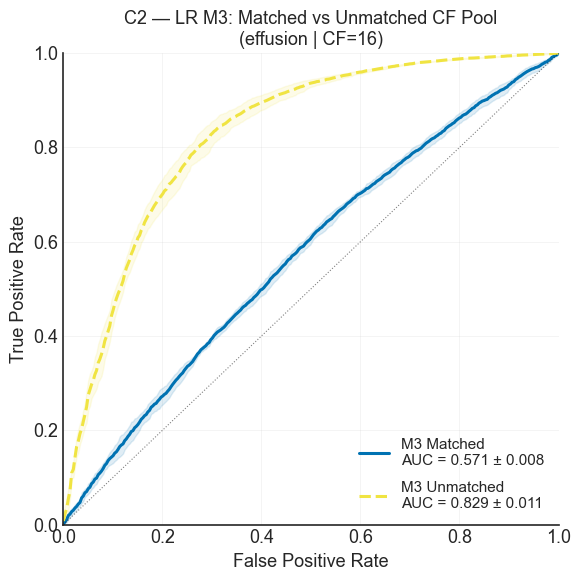

In [39]:
# ── Load matched / unmatched split data ───────────────────────────────────────
matched_json   = f'/zhome/d0/a/221493/thesis/results/C2_custom_corrected/{DISEASE}/cv_results/cf_{CF_COUNT}/cv_detailed.json'
unmatched_json = f'/zhome/d0/a/221493/thesis/results/C2_custom_corrected/{DISEASE}/cv_results_unmatched/cf_{CF_COUNT}/cv_detailed.json'

with open(matched_json)   as f: matched_data   = json.load(f)
with open(unmatched_json) as f: unmatched_data = json.load(f)

model_type = 'LR'
config     = 'M3'

matched   = load_roc(matched_data,   model_type, config)
unmatched = load_roc(unmatched_data, model_type, config)

fig, ax = plt.subplots(figsize=(6, 6))
for d, label, color, ls in [
    (matched,   'M3 Matched',   COLORS['M3'], LINESTYLES['M3']),
    (unmatched, 'M3 Unmatched', COLORS['B3'], LINESTYLES['B3']),
]:
    ax.plot(common_fpr, d['tpr'], color=color, lw=LINEWIDTHS['M3'], ls=ls,
            label=f"{label}\nAUC = {d['auc']:.3f} ± {d['auc_std']:.3f}")
    ax.fill_between(common_fpr, d['tpr'] - d['std'], d['tpr'] + d['std'],
                    color=color, alpha=0.12)
ax.plot([0, 1], [0, 1], 'k:', lw=0.8, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'C2 — {model_type} {config}: Matched vs Unmatched CF Pool\n({DISEASE} | CF={CF_COUNT})')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(loc='lower right', framealpha=0.95, edgecolor='#cccccc', handlelength=2, labelspacing=0.8)
ax.grid(alpha=0.30, linewidth=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'roc_matched_vs_unmatched_{DISEASE}_cf{CF_COUNT}.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. CF Pool Offset Effect

In [55]:
# Load offset comparison data files

CF_COUNT = 1

offset0_json = f'/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_{CF_COUNT}/cv_detailed.json'
offset3_json = f'/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_{CF_COUNT}/k_offset_3/cv_detailed.json'
offset_6_json = f'/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_{CF_COUNT}/k_offset_6/cv_detailed.json'
offset_9_json = f'/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_{CF_COUNT}/k_offset_9/cv_detailed.json'
offset_12_json = f'/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_{CF_COUNT}/k_offset_12/cv_detailed.json'

with open(offset0_json) as f:
    offset0_data = json.load(f)
with open(offset3_json) as f:
    offset3_data = json.load(f)
with open(offset_6_json) as f:
    offset6_data = json.load(f)
with open(offset_9_json) as f:
    offset9_data = json.load(f)
with open(offset_12_json) as f:
    offset12_data = json.load(f)

In [ ]:
model_type = 'LR'
config = 'M6'

offset0  = load_roc(offset0_data,  model_type, config)
offset3  = load_roc(offset3_data,  model_type, config)
offset6  = load_roc(offset6_data,  model_type, config)
offset9  = load_roc(offset9_data,  model_type, config)
offset12 = load_roc(offset12_data, model_type, config)

for label, d in [('Offset 0', offset0), ('Offset 3', offset3), ('Offset 6', offset6),
                  ('Offset 9', offset9), ('Offset 12', offset12)]:
    print(f"{label} AUC: {d['auc']:.3f} ± {d['auc_std']:.3f}")

fig, ax = plt.subplots(figsize=(6, 6))
for d, label, color, ls in [
    (offset0,  'Offset 0',  COLORS['B1'], LINESTYLES['B1']),
    (offset3,  'Offset 3',  COLORS['B2'], LINESTYLES['B2']),
    (offset6,  'Offset 6',  COLORS['B4'], LINESTYLES['B4']),
    (offset9,  'Offset 9',  COLORS['M3'], LINESTYLES['M3']),
    (offset12, 'Offset 12', '#117777', '-'),
]:
    ax.plot(common_fpr, d['tpr'], color=color, lw=LINEWIDTHS['M3'], ls=ls,
            label=f"{label}\nAUC = {d['auc']:.3f} ± {d['auc_std']:.3f}")
    ax.fill_between(common_fpr, d['tpr'] - d['std'], d['tpr'] + d['std'],
                    color=color, alpha=0.12)
ax.plot([0, 1], [0, 1], 'k:', lw=0.8, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'C2 — {model_type} {config}: Effect of CF Pool Offset')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(loc='lower right', prop={'family': 'monospace', 'size': 11},
          framealpha=0.95, edgecolor='#cccccc', handlelength=2, labelspacing=0.8)
ax.grid(alpha=0.30, linewidth=0.5)
plt.tight_layout()
plt.show()

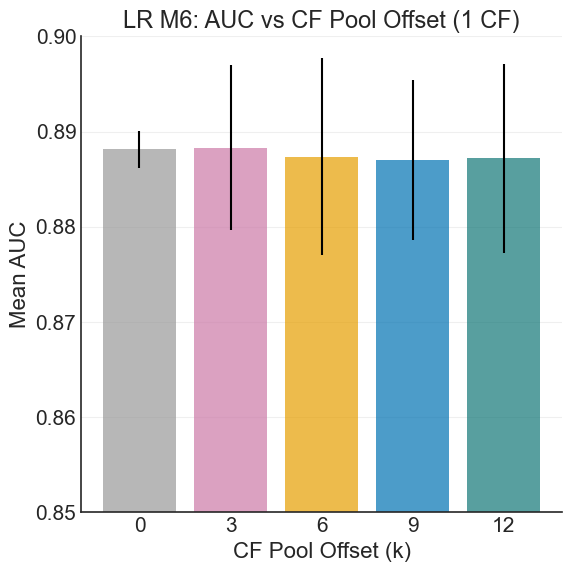

In [61]:
# pLOT BAR PLOT FOR AUC VS OFFSET
plt.figure(figsize=(6,6))
offsets = ['0', '3', '6', '9', '12']
aucs = [offset0['auc'], offset3['auc'], offset6['auc'], offset9['auc'], offset12['auc']]
auc_stds = [offset0['auc_std'], offset3['auc_std'], offset6['auc_std'], offset9['auc_std'], offset12['auc_std']]
plt.bar(offsets, aucs, yerr=auc_stds, color=[COLORS['B1'], COLORS['B2'], COLORS['B4'], COLORS['M3'], '#117777'], alpha=0.7)    
plt.xlabel('CF Pool Offset (k)')
plt.ylabel('Mean AUC')
plt.title(f'{model_type} {config}: AUC vs CF Pool Offset ({CF_COUNT} CF)')
plt.grid(axis='y', alpha=0.3)
plt.ylim(0.85,0.9)
plt.tight_layout()
plt.show()

## 7. C2 CNN Architectures — kNN vs Diffusion Counterfactuals

End-to-end CNNs that take the image (and its counterfactual / saliency map) directly,
rather than the tabular feature vectors used in sections 2–6.

- **kNN-CF** (`code/CNN_baselines/c2_cnn_all.py`) — 6 configs, swept over `cf_count ∈ {1, 5, 16}`,
  trained on the same folds as `cv_results_correct_cf`.
- **Diffusion-CF** (`code/CNN_baselines/c2_cnn_diffusion.py`) — 8 configs at a single CF setting
  (`t_start=50`, `guidance=0.025`); this manifest carries one CF per query, so there is no CF sweep.

Not every run has finished. Configs with no `cv_detailed.json` are skipped; runs that stopped
before all 5 folds are marked with `*` and hatched bars.

In [4]:
# ── C2 CNN results: config registry, paths, availability ──────────────────────
CNN_DISEASE   = DISEASE          # only 'effusion' has CNN runs so far
CF_COUNTS_CNN = [1, 5, 16]
_base = '/zhome/d0/a/221493/thesis/results'
N_FOLDS_EXPECTED = 5

# Colour keyed on input family, linestyle on saliency (dashed = no saliency map).
KNN_CNN = {
    'xi':       dict(dir='baseline',          label='CNN Xi',           color='#4477AA', ls='--'),
    'xi_sal':   dict(dir='baseline_saliency', label='CNN Xi + Sal',     color='#4477AA', ls='-'),
    'cf':       dict(dir='cf_baseline',       label='CNN CF',           color='#5D946D', ls='--'),
    'cf_sal':   dict(dir='cf_saliency',       label='CNN CF + Sal',     color='#5D946D', ls='-'),
    'dual':     dict(dir='dual',              label='CNN Dual (Xi+CF)', color='#BE324A', ls='--'),
    'dual_sal': dict(dir='dual_saliency',     label='CNN Dual + Sal',   color='#BE324A', ls='-'),
}

DIFF_TAG = '50_0.025'   # t_start _ guidance_weight
DIFF_CNN = {
    'xi':                  dict(dir='xi',                  label='CNN Xi',                   color='#4477AA', ls='--'),
    'xi_saliency':         dict(dir='xi_saliency',         label='CNN Xi + Sal',             color='#4477AA', ls='-'),
    'cf':                  dict(dir='cf',                  label='CNN CF',                   color='#5D946D', ls='--'),
    'diff_map':            dict(dir='diff_map',            label='CNN Xi\u2212CF (diff map)',    color='#5D946D', ls='-'),
    'xi_cf':               dict(dir='xi_cf',               label='CNN Xi + CF',              color='#BE324A', ls='--'),
    'xi_cf_diff':          dict(dir='xi_cf_diff',          label='CNN Xi + CF + diff',       color='#BE324A', ls='-'),
    'xi_saliency_cf':      dict(dir='xi_saliency_cf',      label='CNN Xi + Sal + CF',        color='#9370DB', ls='--'),
    'xi_cf_saliency_diff': dict(dir='xi_cf_saliency_diff', label='CNN Xi + CF + Sal + diff', color='#9370DB', ls='-'),
}


def load_cnn_roc(*candidate_paths):
    """Averaged ROC for one CNN run, or None if it has not written cv_detailed.json yet.

    Adds 'n_folds' / 'partial' so plots can flag runs that stopped early.
    """
    path = next((p for p in candidate_paths if os.path.exists(p)), None)
    if path is None:
        return None
    with open(path) as fh:
        folds = json.load(fh)
    if not folds:
        return None
    roc = load_roc_folds(folds)
    roc['n_folds'] = len(folds)
    roc['partial'] = len(folds) < N_FOLDS_EXPECTED
    return roc


def knn_cnn_roc(key, cf):
    return load_cnn_roc(f"{_base}/C2_cnn/{KNN_CNN[key]['dir']}/{CNN_DISEASE}/cf_{cf}/cv_detailed.json")


def diff_cnn_roc(key):
    d = DIFF_CNN[key]['dir']
    return load_cnn_roc(
        f"{_base}/C2_cnn_diffusion/{d}/{CNN_DISEASE}/{DIFF_TAG}/cv_detailed.json",
        # an earlier version of c2_cnn_diffusion.py nested xi_cf under xi/
        f"{_base}/C2_cnn_diffusion/xi/{d}/{CNN_DISEASE}/{DIFF_TAG}/cv_detailed.json",
    )


def b1_reference(cf):
    """B1 (C0 prob only, LR) on the same folds the kNN CNNs were trained on."""
    p = f'{_base}/C2_custom_corrected/{CNN_DISEASE}/cv_results_correct_cf/cf_{cf}/cv_detailed.json'
    if not os.path.exists(p):
        return None
    with open(p) as fh:
        return load_roc_folds(json.load(fh)['LR']['B1'])


# ── Load everything up front; runs that have not produced results stay None ────
knn_roc  = {cf: {k: knn_cnn_roc(k, cf) for k in KNN_CNN} for cf in CF_COUNTS_CNN}
diff_roc = {k: diff_cnn_roc(k) for k in DIFF_CNN}
b1_roc   = {cf: b1_reference(cf) for cf in CF_COUNTS_CNN}


def _status(r):
    if r is None:
        return 'not run'
    return 'ok' if not r['partial'] else f"partial {r['n_folds']}/{N_FOLDS_EXPECTED}"


print(f'kNN-CF CNNs \u2014 {CNN_DISEASE}')
print(pd.DataFrame({
    f'cf={cf}': {KNN_CNN[k]['label']: _status(knn_roc[cf][k]) for k in KNN_CNN}
    for cf in CF_COUNTS_CNN
}).to_string())

print(f'\nDiffusion-CF CNNs \u2014 {CNN_DISEASE} | t_start/guidance = {DIFF_TAG}')
for k, cfg in DIFF_CNN.items():
    print(f"  {cfg['label']:<34} {_status(diff_roc[k])}")

kNN-CF CNNs — effusion
                         cf=1     cf=5    cf=16
CNN Xi                     ok  not run  not run
CNN Xi + Sal               ok       ok       ok
CNN CF                     ok  not run  not run
CNN CF + Sal               ok       ok  not run
CNN Dual (Xi+CF)           ok  not run  not run
CNN Dual + Sal    partial 3/5  not run  not run

Diffusion-CF CNNs — effusion | t_start/guidance = 50_0.025
  CNN Xi                             ok
  CNN Xi + Sal                       ok
  CNN CF                             ok
  CNN Xi−CF (diff map)               ok
  CNN Xi + CF                        ok
  CNN Xi + CF + diff                 ok
  CNN Xi + Sal + CF                  not run
  CNN Xi + CF + Sal + diff           not run


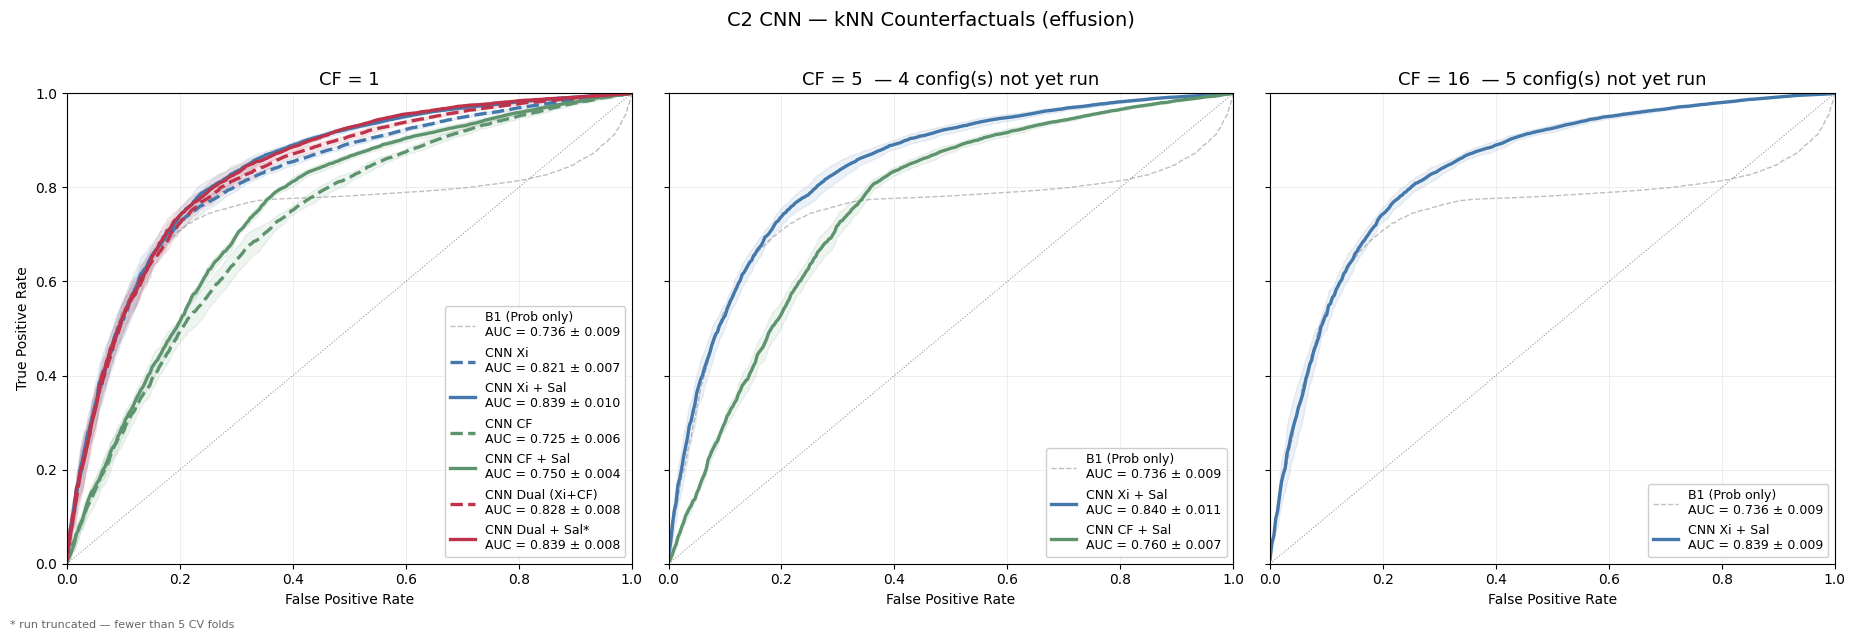

In [5]:
# ── ROC: kNN-CF CNN configs, one panel per CF count ───────────────────────────
cfs_with_data = [cf for cf in CF_COUNTS_CNN if any(knn_roc[cf][k] for k in KNN_CNN)]

fig, axes = plt.subplots(1, len(cfs_with_data), figsize=(6.2 * len(cfs_with_data), 6),
                         squeeze=False, sharey=True)
axes = axes[0]

for ax, cf in zip(axes, cfs_with_data):
    b1 = b1_roc[cf]
    if b1 is not None:
        ax.plot(b1['fpr'], b1['tpr'], color=COLORS['B1'], lw=LINEWIDTHS['B1'], ls=LINESTYLES['B1'],
                zorder=1, label=f"B1 (Prob only)\nAUC = {b1['auc']:.3f} \u00b1 {b1['auc_std']:.3f}")

    for key, cfg in KNN_CNN.items():
        d = knn_roc[cf][key]
        if d is None:
            continue
        star = '*' if d['partial'] else ''
        ax.plot(d['fpr'], d['tpr'], color=cfg['color'], lw=2.4, ls=cfg['ls'],
                label=f"{cfg['label']}{star}\nAUC = {d['auc']:.3f} \u00b1 {d['auc_std']:.3f}")
        ax.fill_between(d['fpr'], d['tpr'] - d['std'], d['tpr'] + d['std'],
                        color=cfg['color'], alpha=0.10)

    n_missing = sum(knn_roc[cf][k] is None for k in KNN_CNN)
    subtitle = f'CF = {cf}' + (f'  \u2014 {n_missing} config(s) not yet run' if n_missing else '')
    ax.plot([0, 1], [0, 1], 'k:', lw=0.8, alpha=0.4)
    ax.set_xlabel('False Positive Rate')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(subtitle, size=13)
    ax.legend(loc='lower right', fontsize=9, framealpha=0.95,
              edgecolor='#cccccc', handlelength=2, labelspacing=0.6)
    ax.grid(alpha=0.30, linewidth=0.5)

axes[0].set_ylabel('True Positive Rate')
if any(d is not None and d['partial'] for cf in cfs_with_data for d in knn_roc[cf].values()):
    fig.text(0.005, -0.01, '* run truncated \u2014 fewer than 5 CV folds', fontsize=8, color='#666666')
fig.suptitle(f'C2 CNN \u2014 kNN Counterfactuals ({CNN_DISEASE})', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'roc_cnn_knn_by_cf_{CNN_DISEASE}.png'), dpi=150, bbox_inches='tight')
plt.show()

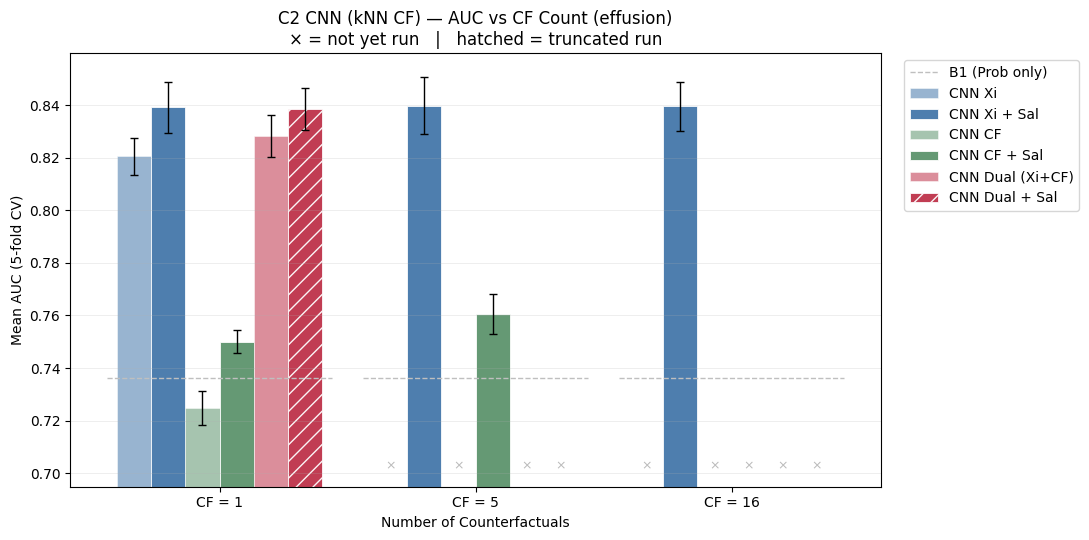

In [6]:
# ── AUC vs CF count, grouped by config (gaps = runs not yet finished) ─────────
fig, ax = plt.subplots(figsize=(11, 5.5))
x     = np.arange(len(CF_COUNTS_CNN))
width = 0.8 / len(KNN_CNN)

_all_aucs = [d['auc'] for cf in CF_COUNTS_CNN for d in knn_roc[cf].values() if d]
_lo, _hi  = min(_all_aucs) - 0.03, max(_all_aucs) + 0.02
_missing_y = _lo + 0.008

labelled = set()
for i, (key, cfg) in enumerate(KNN_CNN.items()):
    offset = (i - (len(KNN_CNN) - 1) / 2) * width
    for j, cf in enumerate(CF_COUNTS_CNN):
        d = knn_roc[cf][key]
        if d is None:
            ax.text(x[j] + offset, _missing_y, '\u00d7', ha='center', va='center',
                    fontsize=9, color='#bbbbbb')
            continue
        ax.bar(x[j] + offset, d['auc'], width, yerr=d['auc_std'], capsize=3,
               color=cfg['color'], alpha=0.55 if cfg['ls'] == '--' else 0.95,
               hatch='//' if d['partial'] else None,
               edgecolor='white', linewidth=0.6,
               label=cfg['label'] if key not in labelled else None,
               error_kw=dict(lw=1.0, capthick=1.0))
        labelled.add(key)

# B1 (prob only) reference, per CF count
for j, cf in enumerate(CF_COUNTS_CNN):
    b1 = b1_roc[cf]
    if b1 is None:
        continue
    ax.hlines(b1['auc'], x[j] - 0.44, x[j] + 0.44,
              color=COLORS['B1'], lw=LINEWIDTHS['B1'], ls=LINESTYLES['B1'], zorder=5,
              label='B1 (Prob only)' if 'B1' not in labelled else None)
    labelled.add('B1')

ax.set_xticks(x); ax.set_xticklabels([f'CF = {cf}' for cf in CF_COUNTS_CNN])
ax.set_xlabel('Number of Counterfactuals')
ax.set_ylabel('Mean AUC (5-fold CV)')
ax.set_ylim(_lo, _hi)
ax.set_title(f'C2 CNN (kNN CF) \u2014 AUC vs CF Count ({CNN_DISEASE})\n'
             '\u00d7 = not yet run   |   hatched = truncated run', fontsize=12)
ax.grid(axis='y', alpha=0.3, linewidth=0.5)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10, edgecolor='#cccccc')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'auc_cnn_knn_vs_cf_{CNN_DISEASE}.png'), dpi=150, bbox_inches='tight')
plt.show()

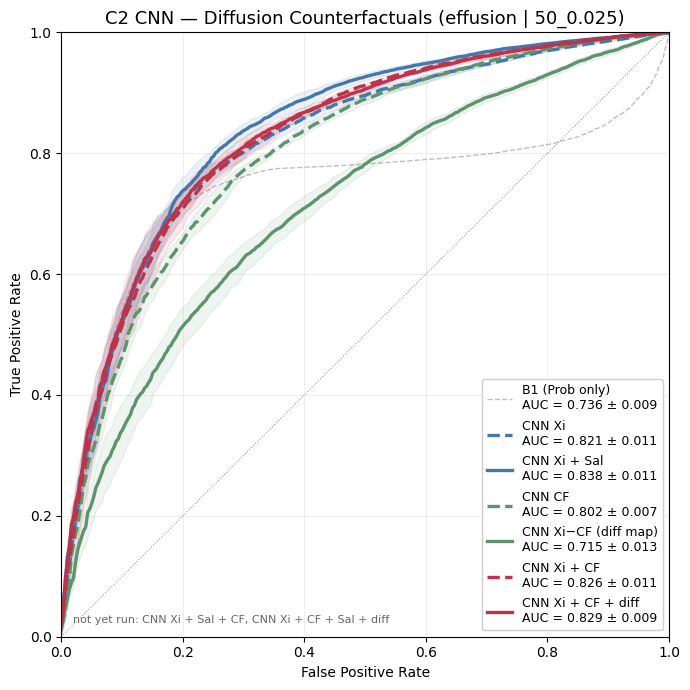

In [7]:
# ── ROC: diffusion-CF CNN configs (single CF setting) ─────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

b1 = b1_roc[1]
if b1 is not None:
    ax.plot(b1['fpr'], b1['tpr'], color=COLORS['B1'], lw=LINEWIDTHS['B1'], ls=LINESTYLES['B1'],
            zorder=1, label=f"B1 (Prob only)\nAUC = {b1['auc']:.3f} \u00b1 {b1['auc_std']:.3f}")

for key, cfg in DIFF_CNN.items():
    d = diff_roc[key]
    if d is None:
        continue
    star = '*' if d['partial'] else ''
    ax.plot(d['fpr'], d['tpr'], color=cfg['color'], lw=2.4, ls=cfg['ls'],
            label=f"{cfg['label']}{star}\nAUC = {d['auc']:.3f} \u00b1 {d['auc_std']:.3f}")
    ax.fill_between(d['fpr'], d['tpr'] - d['std'], d['tpr'] + d['std'],
                    color=cfg['color'], alpha=0.10)

_not_run = [c['label'] for k, c in DIFF_CNN.items() if diff_roc[k] is None]
ax.plot([0, 1], [0, 1], 'k:', lw=0.8, alpha=0.4)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title(f'C2 CNN \u2014 Diffusion Counterfactuals ({CNN_DISEASE} | {DIFF_TAG})', fontsize=13)
ax.legend(loc='lower right', fontsize=9, framealpha=0.95,
          edgecolor='#cccccc', handlelength=2, labelspacing=0.6)
ax.grid(alpha=0.30, linewidth=0.5)
if _not_run:
    ax.annotate('not yet run: ' + ', '.join(_not_run), xy=(0.02, 0.02), xycoords='axes fraction',
                fontsize=8, color='#666666', ha='left', va='bottom')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'roc_cnn_diffusion_{CNN_DISEASE}.png'), dpi=150, bbox_inches='tight')
plt.show()

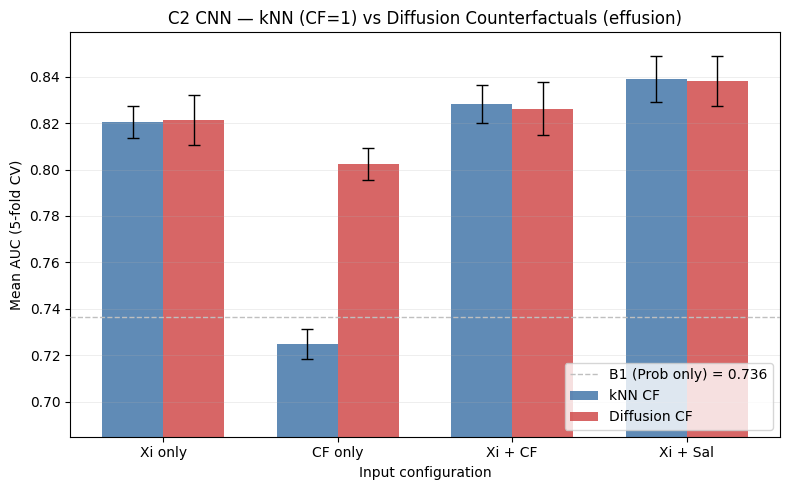

In [8]:
# ── kNN vs diffusion CF, on the three input configs both pipelines share ──────
# The diffusion manifest holds one CF per query, so the fair kNN comparison is cf=1.
SHARED = [
    ('Xi only',      'xi',     'xi'),
    ('CF only',      'cf',     'cf'),
    ('Xi + CF',      'dual',   'xi_cf'),
    ('Xi + Sal',     'xi_sal', 'xi_saliency'),
]

rows = []
for label, knn_key, diff_key in SHARED:
    k, dd = knn_roc[1][knn_key], diff_roc[diff_key]
    rows.append((label, k, dd))

fig, ax = plt.subplots(figsize=(8, 5))
x, width = np.arange(len(rows)), 0.35

for k_idx, (src_label, color, idx) in enumerate([('kNN CF', '#4477AA', 1), ('Diffusion CF', '#D04B4B', 2)]):
    vals = [(r[idx]['auc'] if r[idx] else np.nan) for r in rows]
    errs = [(r[idx]['auc_std'] if r[idx] else 0.0) for r in rows]
    ax.bar(x + (k_idx - 0.5) * width, vals, width, yerr=errs, capsize=4,
           color=color, alpha=0.85, label=src_label, error_kw=dict(lw=1.0, capthick=1.0))

b1 = b1_roc[1]
if b1 is not None:
    ax.axhline(b1['auc'], color=COLORS['B1'], lw=LINEWIDTHS['B1'], ls=LINESTYLES['B1'],
               zorder=5, label=f"B1 (Prob only) = {b1['auc']:.3f}")

_vals = [r[i]['auc'] for r in rows for i in (1, 2) if r[i]]
ax.set_xticks(x); ax.set_xticklabels([r[0] for r in rows])
ax.set_xlabel('Input configuration'); ax.set_ylabel('Mean AUC (5-fold CV)')
ax.set_ylim(min(_vals) - 0.04, max(_vals) + 0.02)
ax.set_title(f'C2 CNN \u2014 kNN (CF=1) vs Diffusion Counterfactuals ({CNN_DISEASE})', fontsize=12)
ax.grid(axis='y', alpha=0.3, linewidth=0.5)
ax.legend(loc='lower right', fontsize=10, edgecolor='#cccccc')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'auc_cnn_knn_vs_diffusion_{CNN_DISEASE}.png'), dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ── Summary table: every CNN run, kNN sweep + diffusion ───────────────────────
def _fmt(d):
    if d is None:
        return '\u2014'
    return f"{d['auc']:.3f} \u00b1 {d['auc_std']:.3f}" + ('*' if d['partial'] else '')

knn_tbl = pd.DataFrame(
    {f'kNN cf={cf}': {KNN_CNN[k]['label']: _fmt(knn_roc[cf][k]) for k in KNN_CNN}
     for cf in CF_COUNTS_CNN}
)
knn_tbl.index.name = 'Config'

diff_tbl = pd.DataFrame(
    {f'Diffusion {DIFF_TAG}': {DIFF_CNN[k]['label']: _fmt(diff_roc[k]) for k in DIFF_CNN}}
)
diff_tbl.index.name = 'Config'

print(f"C2 CNN AUC summary \u2014 {CNN_DISEASE}   (\u2014 = not run, * = truncated)\n{'=' * 72}")
print('\nkNN counterfactuals\n')
print(knn_tbl.to_string())
print('\nDiffusion counterfactuals\n')
print(diff_tbl.to_string())
b1 = b1_roc[1]
if b1 is not None:
    print(f"\nB1 reference (C0 prob only, LR): {b1['auc']:.3f} \u00b1 {b1['auc_std']:.3f}")

csv_path = os.path.join(OUTPUT_DIR, f'auc_cnn_summary_{CNN_DISEASE}.csv')
pd.concat([knn_tbl, diff_tbl], axis=1).to_csv(csv_path)
print(f'\nSaved \u2192 {csv_path}')

C2 CNN AUC summary — effusion   (— = not run, * = truncated)

kNN counterfactuals

                        kNN cf=1       kNN cf=5      kNN cf=16
Config                                                        
CNN Xi             0.821 ± 0.007              —              —
CNN Xi + Sal       0.839 ± 0.010  0.840 ± 0.011  0.839 ± 0.009
CNN CF             0.725 ± 0.006              —              —
CNN CF + Sal       0.750 ± 0.004  0.760 ± 0.007              —
CNN Dual (Xi+CF)   0.828 ± 0.008              —              —
CNN Dual + Sal    0.839 ± 0.008*              —              —

Diffusion counterfactuals

                         Diffusion 50_0.025
Config                                     
CNN CF                        0.802 ± 0.007
CNN Xi                        0.821 ± 0.011
CNN Xi + CF                   0.826 ± 0.011
CNN Xi + CF + Sal + diff                  —
CNN Xi + CF + diff            0.829 ± 0.009
CNN Xi + Sal                  0.838 ± 0.011
CNN Xi + Sal + CF                

## 8. Early-Fusion CNN Architectures

`code/CNN_baselines/c2_cnn_early_fusion.py` is the early-fusion counterpart to the late-fusion
CNNs in section 7: instead of giving each input its own DenseNet and concatenating the pooled
embeddings, all inputs are channel-concatenated into one multi-channel image fed to a single
DenseNet (conv0 inflated from 3 to C channels). Because xi, its CF, and their Grad-CAMs are
pixel-aligned, the first conv layer can compare the same region across inputs.

Same six configs, same `cf_count ∈ {1, 5, 16}` sweep, and — importantly — the same folds
(`cv_results_correct_cf/cf_{K}`), seed and 5-fold protocol as section 7, so the AUCs here are
directly comparable to the late-fusion ones and to the B1 reference line.

Results land in `results/C2_cnn/early_*` with the identical `cv_detailed.json` schema.
Note that the JSON is written only **after** all 5 folds complete, so a job that is still
running shows as `not run` even though its `fold_*_*.npy` artefacts exist.

In [ ]:
# ── Early-fusion CNN results: registry, paths, availability ───────────────────
# Reuses load_cnn_roc / b1_reference / load_roc_folds from section 7 — run that first.
CF_COUNTS_EARLY = CF_COUNTS_CNN

EARLY_CNN = {
    'xi':       dict(dir='early_baseline',          label='Early Xi',           color='#4477AA', ls='--'),
    'xi_sal':   dict(dir='early_baseline_saliency', label='Early Xi + Sal',     color='#4477AA', ls='-'),
    'cf':       dict(dir='early_cf_baseline',       label='Early CF',           color='#5D946D', ls='--'),
    'cf_sal':   dict(dir='early_cf_saliency',       label='Early CF + Sal',     color='#5D946D', ls='-'),
    'dual':     dict(dir='early_dual',              label='Early Dual (Xi+CF)', color='#BE324A', ls='--'),
    'dual_sal': dict(dir='early_dual_saliency',     label='Early Dual + Sal',   color='#BE324A', ls='-'),
}


def early_cnn_roc(key, cf):
    return load_cnn_roc(f"{_base}/C2_cnn/{EARLY_CNN[key]['dir']}/{CNN_DISEASE}/cf_{cf}/cv_detailed.json")


early_roc = {cf: {k: early_cnn_roc(k, cf) for k in EARLY_CNN} for cf in CF_COUNTS_EARLY}

print(f'Early-fusion CNNs \u2014 {CNN_DISEASE}')
print(pd.DataFrame({
    f'cf={cf}': {EARLY_CNN[k]['label']: _status(early_roc[cf][k]) for k in EARLY_CNN}
    for cf in CF_COUNTS_EARLY
}).to_string())

_n_early = sum(r is not None for cf in CF_COUNTS_EARLY for r in early_roc[cf].values())
print(f'\n{_n_early} of {len(EARLY_CNN) * len(CF_COUNTS_EARLY)} early-fusion runs have results.')

In [ ]:
# ── ROC: early-fusion configs, one panel per CF count ─────────────────────────
early_cfs = [cf for cf in CF_COUNTS_EARLY if any(early_roc[cf][k] for k in EARLY_CNN)]

if not early_cfs:
    print('No early-fusion run has written cv_detailed.json yet \u2014 nothing to plot.')
else:
    fig, axes = plt.subplots(1, len(early_cfs), figsize=(6.2 * len(early_cfs), 6),
                             squeeze=False, sharey=True)
    axes = axes[0]

    for ax, cf in zip(axes, early_cfs):
        b1 = b1_roc[cf]
        if b1 is not None:
            ax.plot(b1['fpr'], b1['tpr'], color=COLORS['B1'], lw=LINEWIDTHS['B1'], ls=LINESTYLES['B1'],
                    zorder=1, label=f"B1 (Prob only)\nAUC = {b1['auc']:.3f} \u00b1 {b1['auc_std']:.3f}")

        for key, cfg in EARLY_CNN.items():
            d = early_roc[cf][key]
            if d is None:
                continue
            star = '*' if d['partial'] else ''
            ax.plot(d['fpr'], d['tpr'], color=cfg['color'], lw=2.4, ls=cfg['ls'],
                    label=f"{cfg['label']}{star}\nAUC = {d['auc']:.3f} \u00b1 {d['auc_std']:.3f}")
            ax.fill_between(d['fpr'], d['tpr'] - d['std'], d['tpr'] + d['std'],
                            color=cfg['color'], alpha=0.10)

        n_missing = sum(early_roc[cf][k] is None for k in EARLY_CNN)
        ax.plot([0, 1], [0, 1], 'k:', lw=0.8, alpha=0.4)
        ax.set_xlabel('False Positive Rate')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_title(f'CF = {cf}' + (f'  \u2014 {n_missing} config(s) not yet run' if n_missing else ''), size=13)
        ax.legend(loc='lower right', fontsize=9, framealpha=0.95,
                  edgecolor='#cccccc', handlelength=2, labelspacing=0.6)
        ax.grid(alpha=0.30, linewidth=0.5)

    axes[0].set_ylabel('True Positive Rate')
    if any(d is not None and d['partial'] for cf in early_cfs for d in early_roc[cf].values()):
        fig.text(0.005, -0.01, '* run truncated \u2014 fewer than 5 CV folds', fontsize=8, color='#666666')
    fig.suptitle(f'C2 CNN \u2014 Early Fusion ({CNN_DISEASE})', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'roc_cnn_early_by_cf_{CNN_DISEASE}.png'), dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# ── AUC vs CF count, grouped by early-fusion config ───────────────────────────
_early_aucs = [d['auc'] for cf in CF_COUNTS_EARLY for d in early_roc[cf].values() if d]

if not _early_aucs:
    print('No early-fusion AUCs available yet \u2014 nothing to plot.')
else:
    fig, ax = plt.subplots(figsize=(11, 5.5))
    x     = np.arange(len(CF_COUNTS_EARLY))
    width = 0.8 / len(EARLY_CNN)

    _b1_vals = [b1_roc[cf]['auc'] for cf in CF_COUNTS_EARLY if b1_roc[cf]]
    _lo = min(_early_aucs + _b1_vals) - 0.03
    _hi = max(_early_aucs + _b1_vals) + 0.02
    _missing_y = _lo + 0.008

    labelled = set()
    for i, (key, cfg) in enumerate(EARLY_CNN.items()):
        offset = (i - (len(EARLY_CNN) - 1) / 2) * width
        for j, cf in enumerate(CF_COUNTS_EARLY):
            d = early_roc[cf][key]
            if d is None:
                ax.text(x[j] + offset, _missing_y, '\u00d7', ha='center', va='center',
                        fontsize=9, color='#bbbbbb')
                continue
            ax.bar(x[j] + offset, d['auc'], width, yerr=d['auc_std'], capsize=3,
                   color=cfg['color'], alpha=0.55 if cfg['ls'] == '--' else 0.95,
                   hatch='//' if d['partial'] else None,
                   edgecolor='white', linewidth=0.6,
                   label=cfg['label'] if key not in labelled else None,
                   error_kw=dict(lw=1.0, capthick=1.0))
            labelled.add(key)

    # B1 (prob only) reference, per CF count
    for j, cf in enumerate(CF_COUNTS_EARLY):
        b1 = b1_roc[cf]
        if b1 is None:
            continue
        ax.hlines(b1['auc'], x[j] - 0.44, x[j] + 0.44,
                  color=COLORS['B1'], lw=LINEWIDTHS['B1'], ls=LINESTYLES['B1'], zorder=5,
                  label='B1 (Prob only)' if 'B1' not in labelled else None)
        labelled.add('B1')

    ax.set_xticks(x); ax.set_xticklabels([f'CF = {cf}' for cf in CF_COUNTS_EARLY])
    ax.set_xlabel('Number of Counterfactuals')
    ax.set_ylabel('Mean AUC (5-fold CV)')
    ax.set_ylim(_lo, _hi)
    ax.set_title(f'C2 CNN (early fusion) \u2014 AUC vs CF Count ({CNN_DISEASE})\n'
                 '\u00d7 = not yet run   |   hatched = truncated run', fontsize=12)
    ax.grid(axis='y', alpha=0.3, linewidth=0.5)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10, edgecolor='#cccccc')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'auc_cnn_early_vs_cf_{CNN_DISEASE}.png'), dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# ── Summary table: early-fusion sweep ─────────────────────────────────────────
early_tbl = pd.DataFrame(
    {f'early cf={cf}': {EARLY_CNN[k]['label']: _fmt(early_roc[cf][k]) for k in EARLY_CNN}
     for cf in CF_COUNTS_EARLY}
)
early_tbl.index.name = 'Config'

print(f"C2 CNN early-fusion AUC summary \u2014 {CNN_DISEASE}   (\u2014 = not run, * = truncated)\n{'=' * 72}")
print(early_tbl.to_string())

b1 = b1_roc[1]
if b1 is not None:
    print(f"\nB1 reference (C0 prob only, LR): {b1['auc']:.3f} \u00b1 {b1['auc_std']:.3f}")

csv_path = os.path.join(OUTPUT_DIR, f'auc_cnn_early_summary_{CNN_DISEASE}.csv')
early_tbl.to_csv(csv_path)
print(f'\nSaved \u2192 {csv_path}')

## 9. Architecture Generalizability — DenseNet / ResNet / ViT

In [36]:
resnet_effusion_data = "/zhome/d0/a/221493/thesis/results/C2_resnet50/effusion/cv_results/cf_16/cv_detailed.json"
resnet_cardiomegaly_data = "/zhome/d0/a/221493/thesis/results/C2_resnet50/cardiomegaly/cv_results/cf_16/cv_detailed.json"
resnet_pneumothorax_data = "/zhome/d0/a/221493/thesis/results/C2_resnet50/pneumothorax/cv_results/cf_16/cv_detailed.json"

vit_effusion_data = "/zhome/d0/a/221493/thesis/results/C2_vit/effusion/cv_results/cf_16/cv_detailed.json"
vit_cardiomegaly_data = "/zhome/d0/a/221493/thesis/results/C2_vit/cardiomegaly/cv_results/cf_16/cv_detailed.json"
vit_pneumothorax_data = "/zhome/d0/a/221493/thesis/results/C2_vit/pneumothorax/cv_results/cf_16/cv_detailed.json"

densenet_effusion_data = "/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_16/cv_detailed.json"
densenet_cardiomegaly_data = "/zhome/d0/a/221493/thesis/results/C2_custom/cardiomegaly/cv_results/cf_16/cv_detailed.json"
densenet_pneumothorax_data = "/zhome/d0/a/221493/thesis/results/C2_custom/pneumothorax/cv_results/cf_16/cv_detailed.json"

with open(resnet_effusion_data) as f:
    resnet_data = json.load(f)
with open(vit_effusion_data) as f:
    vit_data = json.load(f)
with open(densenet_effusion_data) as f:
    densenet_data = json.load(f)
    
    
with open(resnet_cardiomegaly_data) as f:
    resnet_cardio_data = json.load(f)
with open(vit_cardiomegaly_data) as f:  
    vit_cardiomegaly_data =json.load(f)
with open(densenet_cardiomegaly_data) as f:
    densenet_cardio_data = json.load(f)
    
with open(resnet_pneumothorax_data) as f:
    resnet_pneumo_data = json.load(f)
with open(vit_pneumothorax_data) as f:
    vit_pneumo_data = json.load(f)
with open(densenet_pneumothorax_data) as f:
    densenet_pneumo_data = json.load(f)
    
# PRINT THE ORGANIZATIONS OF THE DATA TO UNDERSTAND HOW TO EXTRACT THE ROC CURVE INFORMATION
print("ResNet Effusion Keys:", resnet_data.keys())
print("ResNet Effusion LR Keys:", resnet_data['LR'].keys())
print("ResNet Effusion M3 Keys:", resnet_data['LR']['M3'][0].keys())
    


ResNet Effusion Keys: dict_keys(['LR', 'RF', 'MLP'])
ResNet Effusion LR Keys: dict_keys(['B1', 'B2', 'B3', 'B4', 'B5', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6'])
ResNet Effusion M3 Keys: dict_keys(['auc', 'fpr', 'tpr', 'y_prob', 'y_true'])


In [ ]:
# ---- C0 val accuracy from your table ----
c0_acc = {
    "DenseNet-121": [91.1, 85.2, 75.9],
    "ResNet-50":    [90.5, 85.9, 75.3],
    "ViT-B/16":     [88.8, 82.7, 56.3],
}

arch_names = ["DenseNet-121", "ResNet-50", "ViT-B/16"]
arch_data  = [densenet_data, resnet_data, vit_data]
diseases   = ["Effusion", "Cardiomegaly", "Pneumothorax"]

c2_aucs = np.zeros((len(arch_names), len(diseases)))
c2_stds = np.zeros((len(arch_names), len(diseases)))

for i, (name, data) in enumerate(zip(arch_names, arch_data)):
    for j, disease in enumerate(diseases):
        folds = data['LR']['M6']
        aucs = [f['auc'] for f in folds]
        c2_aucs[i, j] = np.mean(aucs)
        c2_stds[i, j] = np.std(aucs)

ARCH_COLORS = {
    "DenseNet-121": "#4477AA",
    "ResNet-50":    "#88AACC",
    "ViT-B/16":     "#117777",
}

x, width = np.arange(len(diseases)), 0.25
fig, ax = plt.subplots(figsize=(8, 5))

for i, (name, color) in enumerate(zip(arch_names, ARCH_COLORS.values())):
    c0_str = " / ".join([f"{v:.0f}" for v in c0_acc[name]])
    ax.bar(x + (i - 1) * width, c2_aucs[i], width,
           yerr=c2_stds[i], capsize=4, color=color, linewidth=1.2,
           label=f"{name}  (C0: {c0_str}%)")

ax.set_xticks(x); ax.set_xticklabels(diseases)
ax.set_ylabel("C2 AUC"); ax.set_xlabel("Disease")
ax.set_ylim(0.90, 1.0)
ax.set_title("C2 Generalizability\n(Across Diseases and Architectures)")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Architecture  (C0 val acc: Eff / Card / Pneu)",
          bbox_to_anchor=(1.02, 1), fontsize=12, title_fontsize=12)

_out = "/zhome/d0/a/221493/thesis/results/C2_generalizability"
os.makedirs(_out, exist_ok=True)
plt.savefig(os.path.join(_out, "c2_generalizability_across_diseases.png"), dpi=1200, bbox_inches='tight')
plt.tight_layout()
plt.show()

## 10. Dataset Size Effect

In [21]:
full_set_json = "/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_16/cv_detailed.json"
with open(full_set_json) as f:
    full_set_data = json.load(f)


In [22]:
sub_5k_json = "/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_16_sub5000/cv_detailed.json"
with open(sub_5k_json) as f:
    sub_5k_data = json.load(f)

In [23]:
sub_10k_json = "/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_16_sub10000/cv_detailed.json"
with open(sub_10k_json) as f:
    sub_10k_data = json.load(f)

In [115]:
sub_20k_json = "/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_16_sub20000/cv_detailed.json"
with open(sub_20k_json) as f:
    sub_20k_data = json.load(f)


In [116]:
sub_30k_json = "/zhome/d0/a/221493/thesis/results/C2_custom/effusion/cv_results/cf_16_sub30000/cv_detailed.json"
with open(sub_30k_json) as f:
    sub_30k_data = json.load(f)

In [ ]:
full_set_m3 = load_roc(full_set_data, 'LR', 'M3')
sub_5k_m3   = load_roc(sub_5k_data,   'LR', 'M3')
sub_10k_m3  = load_roc(sub_10k_data,  'LR', 'M3')
sub_20k_m3  = load_roc(sub_20k_data,  'LR', 'M3')
sub_30k_m3  = load_roc(sub_30k_data,  'LR', 'M3')

labels   = ['45k (Full)', '30k', '20k', '10k', '5k']
aucs     = [full_set_m3['auc'], sub_30k_m3['auc'], sub_20k_m3['auc'], sub_10k_m3['auc'], sub_5k_m3['auc']]
auc_stds = [full_set_m3['auc_std'], sub_30k_m3['auc_std'], sub_20k_m3['auc_std'], sub_10k_m3['auc_std'], sub_5k_m3['auc_std']]

plt.figure(figsize=(6, 6))
plt.bar(labels, aucs, yerr=auc_stds, capsize=10,
        color=['#117777', '#88AACC', '#88AACC', '#88AACC', '#88AACC'], linewidth=1.2)
plt.ylabel('AUC (5-fold CV)')
plt.xlabel('Dataset Size')
plt.title(f'C2 (M3 | {CF_COUNT} CF) — Effect of Dataset Size ({DISEASE})', fontsize=14)
plt.ylim(0.95, 1)
plt.grid(axis='y', alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.show()

In [25]:
# Table of results
results_df = pd.DataFrame({
    'Dataset Size': ['45k (Full)', '30k', '20k', '10k', '5k'],
    'AUC': [full_set_m3['auc'], sub_30k_m3['auc'], sub_20k_m3['auc'], sub_10k_m3['auc'], sub_5k_m3['auc']],
    'AUC Std': [full_set_m3['auc_std'], sub_30k_m3['auc_std'], sub_20k_m3['auc_std'], sub_10k_m3['auc_std'], sub_5k_m3['auc_std']]
})
print(results_df.to_string(index=False))

NameError: name 'sub_30k_m3' is not defined

In [ ]:
full_set_m6 = load_roc(full_set_data, 'LR', 'M6')
sub_5k_m6   = load_roc(sub_5k_data,   'LR', 'M6')
sub_10k_m6  = load_roc(sub_10k_data,  'LR', 'M6')
sub_20k_m6  = load_roc(sub_20k_data,  'LR', 'M6')
sub_30k_m6  = load_roc(sub_30k_data,  'LR', 'M6')

labels   = ['45k (Full)', '30k', '20k', '10k', '5k']
aucs     = [full_set_m6['auc'], sub_30k_m6['auc'], sub_20k_m6['auc'], sub_10k_m6['auc'], sub_5k_m6['auc']]
auc_stds = [full_set_m6['auc_std'], sub_30k_m6['auc_std'], sub_20k_m6['auc_std'], sub_10k_m6['auc_std'], sub_5k_m6['auc_std']]

plt.figure(figsize=(6, 6))
plt.bar(labels, aucs, yerr=auc_stds, capsize=10,
        color=['#D04B4B', '#839BB3', '#839BB3', '#839BB3', '#839BB3'], linewidth=1.2)
plt.ylabel('AUC (5-fold CV)')
plt.xlabel('Dataset Size')
plt.title(f'C2 (M6 | {CF_COUNT} CF) — Effect of Dataset Size ({DISEASE})', fontsize=14)
plt.ylim(0.98, 1)
plt.grid(axis='y', alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.show()

In [54]:
# Table of results
results_df = pd.DataFrame({
    'Dataset Size': ['45k (Full)', '30k', '20k', '10k', '5k'],
    'AUC': [full_set_m6['auc'], sub_30k_m6['auc'], sub_20k_m6['auc'], sub_10k_m6['auc'], sub_5k_m6['auc']],
    'AUC Std': [full_set_m6['auc_std'], sub_30k_m6['auc_std'], sub_20k_m6['auc_std'], sub_10k_m6['auc_std'], sub_5k_m6['auc_std']]
})
print(results_df.to_string(index=False))

Dataset Size      AUC  AUC Std
  45k (Full) 0.994986 0.001445
         30k 0.994072 0.001355
         20k 0.995775 0.000951
         10k 0.998052 0.000382
          5k 0.996153 0.003577


In [55]:
latex_table = results_df.to_latex(index=False, float_format="%.4f")
print(latex_table)

\begin{tabular}{lrr}
\toprule
Dataset Size & AUC & AUC Std \\
\midrule
45k (Full) & 0.9950 & 0.0014 \\
30k & 0.9941 & 0.0014 \\
20k & 0.9958 & 0.0010 \\
10k & 0.9981 & 0.0004 \\
5k & 0.9962 & 0.0036 \\
\bottomrule
\end{tabular}



## 11. CF Pool Variant Comparison — Unmatched / Correct CF / Extended Correct CF

In [42]:
# ── Load all 12 result files (3 variants × 4 CF counts) ───────────────────────
COMPARE_DISEASE   = DISEASE
CF_COUNTS_COMPARE = [1, 3, 5, 16]
VARIANTS = {
    'Unmatched':           'cv_results_unmatched',
    'Correct CF':          'cv_results_correct_cf',
    'Extended Correct CF': 'cv_results_extended_correct_cf',
}
BASE = f'/zhome/d0/a/221493/thesis/results/C2_custom_corrected/{COMPARE_DISEASE}'

all_data = {}
for label, folder in VARIANTS.items():
    all_data[label] = {}
    for cf in CF_COUNTS_COMPARE:
        with open(f'{BASE}/{folder}/cf_{cf}/cv_detailed.json') as fh:
            all_data[label][cf] = json.load(fh)
print(f"Loaded {len(VARIANTS)} variants × {len(CF_COUNTS_COMPARE)} CF counts for {COMPARE_DISEASE}.")

Loaded 3 variants × 4 CF counts for effusion.


In [43]:
# ── Comprehensive AUC table: all models × configs × variants × CF counts ───────
_all_configs  = ['B1','B2','B3','B4','B5',
                 'M1','M2','M3','M4','M5','M6',
                 'MCF1','MCF2','MCF3','MCF4','MCF5']
_variant_list = list(VARIANTS.keys())

col_index = pd.MultiIndex.from_product(
    [_variant_list, CF_COUNTS_COMPARE],
    names=['Variant', 'CF count']
)

all_model_dfs = []
for model in MODELS_TO_PLOT:
    rows = {}
    for config in _all_configs:
        row = {}
        for variant_label in _variant_list:
            for cf in CF_COUNTS_COMPARE:
                data = all_data[variant_label][cf]
                if config in data.get(model, {}):
                    r = load_roc(data, model, config)
                    row[(variant_label, cf)] = f"{r['auc']:.3f} ± {r['auc_std']:.3f}"
                else:
                    row[(variant_label, cf)] = '—'
        rows[config] = row

    df = pd.DataFrame(rows, index=col_index).T
    df.index.name = 'Config'
    all_model_dfs.append((model, df))

    print(f"\n{'='*80}")
    print(f"  {MODEL_NAMES[model]}  —  {COMPARE_DISEASE}")
    print(f"{'='*80}")
    display(df)
    print()

# ── Save all to one CSV with flat column names ─────────────────────────────────
csv_parts = []
for model, df in all_model_dfs:
    flat = df.copy()
    flat.columns = [f'{v} | cf={c}' for v, c in flat.columns]
    flat.insert(0, 'Model', model)
    flat.index.name = 'Config'
    csv_parts.append(flat)

combined = pd.concat(csv_parts).reset_index()
csv_path = os.path.join(OUTPUT_DIR, f'auc_all_results_{COMPARE_DISEASE}.csv')
combined.to_csv(csv_path, index=False)
print(f"Saved → {csv_path}")


  Logistic Regression  —  effusion


Variant       Unmatched                                               \
CF count             1              3              5              16   
Config                                                                 
B1        0.736 ± 0.009  0.736 ± 0.009  0.736 ± 0.009  0.736 ± 0.009   
B2        0.799 ± 0.009  0.799 ± 0.009  0.799 ± 0.009  0.799 ± 0.009   
B3        0.828 ± 0.010  0.828 ± 0.010  0.828 ± 0.010  0.828 ± 0.010   
B4        0.833 ± 0.011  0.833 ± 0.011  0.833 ± 0.011  0.833 ± 0.011   
B5        0.831 ± 0.009  0.831 ± 0.009  0.831 ± 0.009  0.831 ± 0.009   
M1        0.796 ± 0.009  0.818 ± 0.011  0.825 ± 0.011  0.831 ± 0.011   
M2        0.797 ± 0.009  0.820 ± 0.011  0.828 ± 0.011  0.833 ± 0.011   
M3        0.821 ± 0.011  0.825 ± 0.011  0.829 ± 0.010  0.829 ± 0.011   
M4        0.823 ± 0.010  0.825 ± 0.012  0.826 ± 0.011  0.827 ± 0.011   
M5        0.815 ± 0.011  0.817 ± 0.011  0.819 ± 0.011  0.820 ± 0.012   
M6        0.821 ± 0.011  0.825 ± 0.011  0.829 ± 0.010  0.829 ± 0.011   
MCF1      0.711 ± 0.009  0.706 ± 0.009  0.708 ± 0.007  0.714 ± 0.007   
MCF2      0.821 ± 0.010  0.824 ± 0.010  0.828 ± 0.009  0.828 ± 0.011   
MCF3      0.820 ± 0.010  0.823 ± 0.010  0.827 ± 0.010  0.827 ± 0.011   
MCF4      0.789 ± 0.011  0.795 ± 0.011  0.796 ± 0.010  0.802 ± 0.009   
MCF5      0.788 ± 0.011  0.794 ± 0.011  0.795 ± 0.010  0.801 ± 0.009   

Variant      Correct CF                                               \
CF count             1              3              5              16   
Config                                                                 
B1        0.736 ± 0.009  0.736 ± 0.009  0.736 ± 0.009  0.736 ± 0.009   
B2        0.799 ± 0.009  0.799 ± 0.009  0.799 ± 0.009  0.799 ± 0.009   
B3        0.828 ± 0.010  0.828 ± 0.010  0.828 ± 0.010  0.828 ± 0.010   
B4        0.833 ± 0.011  0.833 ± 0.011  0.833 ± 0.011  0.833 ± 0.011   
B5        0.831 ± 0.009  0.831 ± 0.009  0.831 ± 0.009  0.831 ± 0.009   
M1        0.799 ± 0.013  0.820 ± 0.011  0.826 ± 0.011  0.831 ± 0.012   
M2        0.799 ± 0.013  0.822 ± 0.011  0.828 ± 0.011  0.834 ± 0.012   
M3        0.824 ± 0.012  0.826 ± 0.010  0.829 ± 0.011  0.830 ± 0.011   
M4        0.824 ± 0.011  0.825 ± 0.012  0.826 ± 0.012  0.826 ± 0.011   
M5        0.815 ± 0.013  0.818 ± 0.011  0.819 ± 0.012  0.820 ± 0.012   
M6        0.824 ± 0.012  0.826 ± 0.010  0.829 ± 0.011  0.830 ± 0.011   
MCF1      0.716 ± 0.007  0.711 ± 0.008  0.715 ± 0.007  0.718 ± 0.007   
MCF2      0.823 ± 0.012  0.825 ± 0.009  0.829 ± 0.011  0.829 ± 0.011   
MCF3      0.822 ± 0.012  0.825 ± 0.010  0.828 ± 0.011  0.828 ± 0.011   
MCF4      0.787 ± 0.011  0.792 ± 0.012  0.794 ± 0.010  0.801 ± 0.008   
MCF5      0.786 ± 0.011  0.791 ± 0.012  0.794 ± 0.010  0.800 ± 0.008   

Variant  Extended Correct CF                                               
CF count                  1              3              5              16  
Config                                                                     
B1             0.736 ± 0.006  0.736 ± 0.006  0.736 ± 0.006  0.736 ± 0.006  
B2             0.794 ± 0.010  0.794 ± 0.010  0.794 ± 0.010  0.794 ± 0.010  
B3             0.827 ± 0.007  0.827 ± 0.007  0.827 ± 0.007  0.827 ± 0.007  
B4             0.828 ± 0.008  0.828 ± 0.008  0.828 ± 0.008  0.828 ± 0.008  
B5             0.830 ± 0.008  0.830 ± 0.008  0.830 ± 0.008  0.830 ± 0.008  
M1             0.786 ± 0.005  0.813 ± 0.007  0.819 ± 0.007  0.825 ± 0.008  
M2             0.786 ± 0.005  0.815 ± 0.007  0.821 ± 0.008  0.827 ± 0.008  
M3             0.809 ± 0.004  0.816 ± 0.008  0.819 ± 0.010  0.820 ± 0.008  
M4             0.813 ± 0.009  0.818 ± 0.009  0.818 ± 0.009  0.820 ± 0.007  
M5             0.802 ± 0.006  0.809 ± 0.009  0.810 ± 0.010  0.811 ± 0.006  
M6             0.809 ± 0.004  0.816 ± 0.008  0.819 ± 0.010  0.820 ± 0.008  
MCF1           0.714 ± 0.007  0.711 ± 0.010  0.715 ± 0.009  0.719 ± 0.009  
MCF2           0.812 ± 0.005  0.817 ± 0.008  0.820 ± 0.010  0.820 ± 0.008  
MCF3           0.807 ± 0.004  0.813 ± 0.009  0



  Random Forest  —  effusion


Variant       Unmatched                                               \
CF count             1              3              5              16   
Config                                                                 
B1        0.753 ± 0.010  0.753 ± 0.010  0.753 ± 0.010  0.753 ± 0.010   
B2        0.778 ± 0.007  0.778 ± 0.007  0.778 ± 0.007  0.778 ± 0.007   
B3        0.845 ± 0.010  0.845 ± 0.010  0.845 ± 0.010  0.845 ± 0.010   
B4        0.826 ± 0.008  0.826 ± 0.008  0.826 ± 0.008  0.826 ± 0.008   
B5        0.846 ± 0.011  0.846 ± 0.011  0.846 ± 0.011  0.846 ± 0.011   
M1        0.805 ± 0.011  0.816 ± 0.009  0.819 ± 0.009  0.829 ± 0.010   
M2        0.829 ± 0.010  0.832 ± 0.010  0.833 ± 0.010  0.836 ± 0.011   
M3        0.834 ± 0.009  0.831 ± 0.011  0.833 ± 0.009  0.836 ± 0.011   
M4        0.847 ± 0.011  0.847 ± 0.008  0.849 ± 0.009  0.847 ± 0.011   
M5        0.848 ± 0.010  0.848 ± 0.011  0.848 ± 0.010  0.848 ± 0.011   
M6        0.837 ± 0.009  0.837 ± 0.009  0.837 ± 0.011  0.837 ± 0.009   
MCF1      0.808 ± 0.009  0.803 ± 0.011  0.803 ± 0.008  0.804 ± 0.006   
MCF2      0.827 ± 0.009  0.828 ± 0.010  0.829 ± 0.009  0.831 ± 0.007   
MCF3      0.834 ± 0.012  0.831 ± 0.011  0.834 ± 0.007  0.837 ± 0.010   
MCF4      0.847 ± 0.007  0.845 ± 0.008  0.847 ± 0.009  0.846 ± 0.010   
MCF5      0.845 ± 0.010  0.845 ± 0.010  0.847 ± 0.010  0.848 ± 0.008   

Variant      Correct CF                                               \
CF count             1              3              5              16   
Config                                                                 
B1        0.753 ± 0.010  0.753 ± 0.010  0.753 ± 0.010  0.753 ± 0.010   
B2        0.778 ± 0.007  0.778 ± 0.007  0.778 ± 0.007  0.778 ± 0.007   
B3        0.845 ± 0.010  0.845 ± 0.010  0.845 ± 0.010  0.845 ± 0.010   
B4        0.826 ± 0.008  0.826 ± 0.008  0.826 ± 0.008  0.826 ± 0.008   
B5        0.846 ± 0.011  0.846 ± 0.011  0.846 ± 0.011  0.846 ± 0.011   
M1        0.804 ± 0.011  0.818 ± 0.012  0.821 ± 0.011  0.830 ± 0.009   
M2        0.828 ± 0.013  0.832 ± 0.008  0.832 ± 0.011  0.836 ± 0.011   
M3        0.833 ± 0.009  0.833 ± 0.008  0.835 ± 0.006  0.835 ± 0.011   
M4        0.847 ± 0.010  0.849 ± 0.010  0.847 ± 0.011  0.847 ± 0.010   
M5        0.847 ± 0.009  0.847 ± 0.010  0.848 ± 0.010  0.847 ± 0.008   
M6        0.837 ± 0.008  0.837 ± 0.011  0.836 ± 0.011  0.838 ± 0.009   
MCF1      0.808 ± 0.012  0.803 ± 0.008  0.801 ± 0.010  0.804 ± 0.006   
MCF2      0.826 ± 0.011  0.830 ± 0.009  0.832 ± 0.007  0.830 ± 0.008   
MCF3      0.830 ± 0.010  0.832 ± 0.009  0.836 ± 0.010  0.835 ± 0.009   
MCF4      0.847 ± 0.008  0.847 ± 0.009  0.848 ± 0.009  0.846 ± 0.010   
MCF5      0.846 ± 0.008  0.846 ± 0.010  0.848 ± 0.009  0.848 ± 0.010   

Variant  Extended Correct CF                                               
CF count                  1              3              5              16  
Config                                                                     
B1             0.751 ± 0.006  0.751 ± 0.006  0.751 ± 0.006  0.751 ± 0.006  
B2             0.774 ± 0.006  0.774 ± 0.006  0.774 ± 0.006  0.774 ± 0.006  
B3             0.845 ± 0.004  0.845 ± 0.004  0.845 ± 0.004  0.845 ± 0.004  
B4             0.818 ± 0.004  0.818 ± 0.004  0.818 ± 0.004  0.818 ± 0.004  
B5             0.846 ± 0.003  0.846 ± 0.003  0.846 ± 0.003  0.846 ± 0.003  
M1             0.797 ± 0.002  0.808 ± 0.004  0.817 ± 0.005  0.821 ± 0.006  
M2             0.822 ± 0.004  0.822 ± 0.005  0.829 ± 0.006  0.832 ± 0.006  
M3             0.826 ± 0.004  0.827 ± 0.006  0.830 ± 0.006  0.833 ± 0.005  
M4             0.845 ± 0.003  0.845 ± 0.003  0.844 ± 0.003  0.846 ± 0.005  
M5             0.845 ± 0.004  0.846 ± 0.003  0.847 ± 0.003  0.845 ± 0.005  
M6             0.830 ± 0.003  0.831 ± 0.007  0.835 ± 0.005  0.833 ± 0.007  
MCF1           0.805 ± 0.004  0.803 ± 0.006  0.799 ± 0.005  0.803 ± 0.006  
MCF2           0.817 ± 0.004  0.824 ± 0.002  0.824 ± 0.004  0.824 ± 0.004  
MCF3           0.824 ± 0.004  0.826 ± 0.006  0



  Multilayer Perceptron  —  effusion


Variant       Unmatched                                               \
CF count             1              3              5              16   
Config                                                                 
B1        0.851 ± 0.011  0.851 ± 0.011  0.851 ± 0.011  0.851 ± 0.011   
B2        0.782 ± 0.018  0.782 ± 0.018  0.782 ± 0.018  0.782 ± 0.018   
B3        0.841 ± 0.009  0.841 ± 0.009  0.841 ± 0.009  0.841 ± 0.009   
B4        0.817 ± 0.014  0.817 ± 0.014  0.817 ± 0.014  0.817 ± 0.014   
B5        0.846 ± 0.007  0.846 ± 0.007  0.846 ± 0.007  0.846 ± 0.007   
M1        0.783 ± 0.005  0.803 ± 0.009  0.801 ± 0.019  0.811 ± 0.010   
M2        0.803 ± 0.012  0.797 ± 0.015  0.813 ± 0.009  0.814 ± 0.008   
M3        0.810 ± 0.008  0.810 ± 0.007  0.811 ± 0.011  0.818 ± 0.012   
M4        0.842 ± 0.010  0.838 ± 0.014  0.841 ± 0.015  0.839 ± 0.015   
M5        0.842 ± 0.007  0.836 ± 0.012  0.847 ± 0.009  0.843 ± 0.012   
M6        0.805 ± 0.007  0.823 ± 0.012  0.825 ± 0.014  0.826 ± 0.013   
MCF1      0.852 ± 0.010  0.848 ± 0.011  0.849 ± 0.011  0.850 ± 0.010   
MCF2      0.808 ± 0.010  0.816 ± 0.012  0.825 ± 0.012  0.822 ± 0.014   
MCF3      0.802 ± 0.014  0.811 ± 0.013  0.809 ± 0.013  0.817 ± 0.008   
MCF4      0.841 ± 0.006  0.841 ± 0.009  0.844 ± 0.008  0.849 ± 0.009   
MCF5      0.834 ± 0.008  0.839 ± 0.012  0.844 ± 0.007  0.844 ± 0.008   

Variant      Correct CF                                               \
CF count             1              3              5              16   
Config                                                                 
B1        0.851 ± 0.011  0.851 ± 0.011  0.851 ± 0.011  0.851 ± 0.011   
B2        0.782 ± 0.018  0.786 ± 0.020  0.786 ± 0.020  0.782 ± 0.018   
B3        0.841 ± 0.009  0.849 ± 0.006  0.849 ± 0.006  0.841 ± 0.009   
B4        0.817 ± 0.014  0.819 ± 0.008  0.819 ± 0.008  0.817 ± 0.014   
B5        0.846 ± 0.007  0.845 ± 0.003  0.845 ± 0.003  0.846 ± 0.007   
M1        0.773 ± 0.024  0.803 ± 0.010  0.803 ± 0.018  0.811 ± 0.013   
M2        0.785 ± 0.022  0.804 ± 0.011  0.815 ± 0.015  0.813 ± 0.013   
M3        0.811 ± 0.012  0.816 ± 0.008  0.816 ± 0.005  0.820 ± 0.008   
M4        0.842 ± 0.004  0.832 ± 0.021  0.843 ± 0.004  0.840 ± 0.017   
M5        0.841 ± 0.009  0.841 ± 0.007  0.840 ± 0.008  0.839 ± 0.017   
M6        0.819 ± 0.009  0.824 ± 0.014  0.823 ± 0.020  0.825 ± 0.012   
MCF1      0.852 ± 0.010  0.850 ± 0.012  0.848 ± 0.010  0.849 ± 0.010   
MCF2      0.809 ± 0.009  0.816 ± 0.010  0.815 ± 0.013  0.820 ± 0.010   
MCF3      0.802 ± 0.026  0.814 ± 0.011  0.818 ± 0.008  0.819 ± 0.008   
MCF4      0.833 ± 0.013  0.841 ± 0.008  0.841 ± 0.011  0.843 ± 0.009   
MCF5      0.836 ± 0.013  0.838 ± 0.004  0.844 ± 0.008  0.839 ± 0.010   

Variant  Extended Correct CF                                               
CF count                  1              3              5              16  
Config                                                                     
B1             0.852 ± 0.006  0.852 ± 0.006  0.852 ± 0.006  0.852 ± 0.006  
B2             0.764 ± 0.010  0.764 ± 0.010  0.764 ± 0.010  0.764 ± 0.010  
B3             0.846 ± 0.005  0.846 ± 0.005  0.846 ± 0.005  0.846 ± 0.005  
B4             0.818 ± 0.008  0.818 ± 0.008  0.818 ± 0.008  0.818 ± 0.008  
B5             0.844 ± 0.009  0.844 ± 0.009  0.844 ± 0.009  0.844 ± 0.009  
M1             0.750 ± 0.010  0.789 ± 0.006  0.793 ± 0.009  0.791 ± 0.009  
M2             0.761 ± 0.012  0.790 ± 0.018  0.804 ± 0.008  0.805 ± 0.008  
M3             0.801 ± 0.004  0.812 ± 0.004  0.808 ± 0.006  0.807 ± 0.008  
M4             0.842 ± 0.004  0.837 ± 0.016  0.846 ± 0.005  0.844 ± 0.006  
M5             0.835 ± 0.009  0.844 ± 0.007  0.839 ± 0.007  0.840 ± 0.007  
M6             0.796 ± 0.010  0.803 ± 0.015  0.814 ± 0.007  0.816 ± 0.004  
MCF1           0.848 ± 0.007  0.848 ± 0.005  0.849 ± 0.006  0.850 ± 0.006  
MCF2           0.811 ± 0.005  0.813 ± 0.007  0.812 ± 0.009  0.818 ± 0.009  
MCF3           0.806 ± 0.007  0.807 ± 0.016  0


Saved → images/auc_all_results_effusion.csv


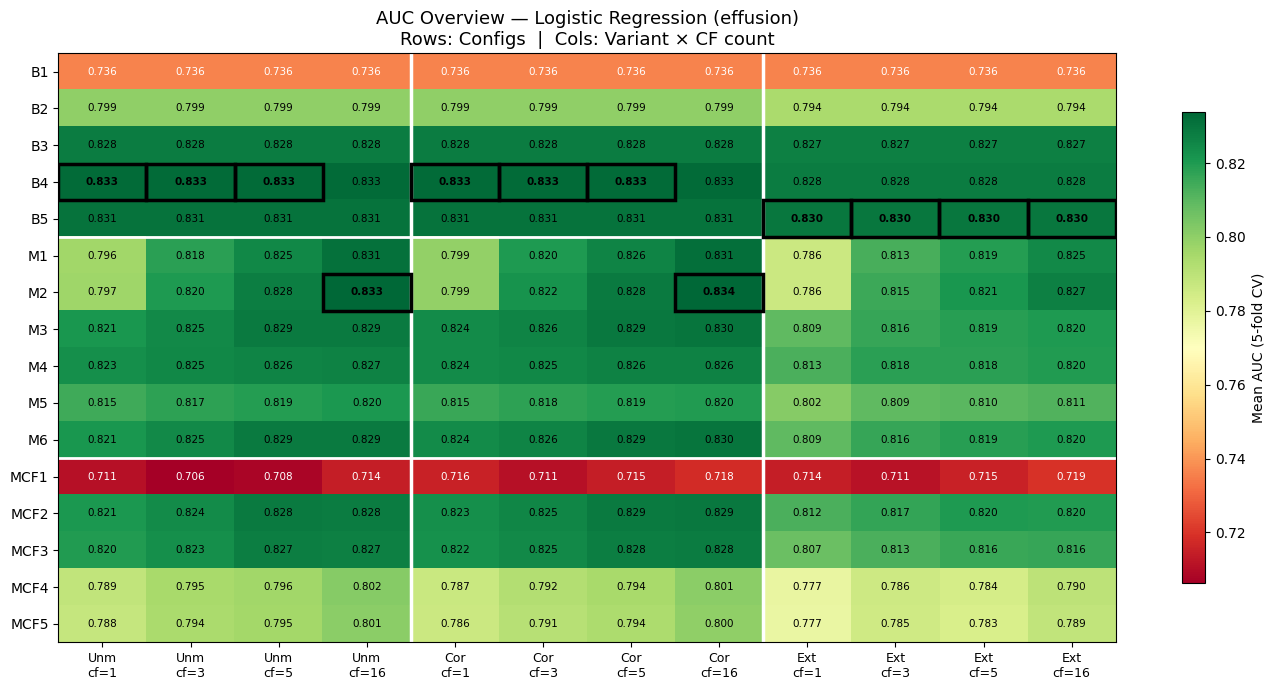

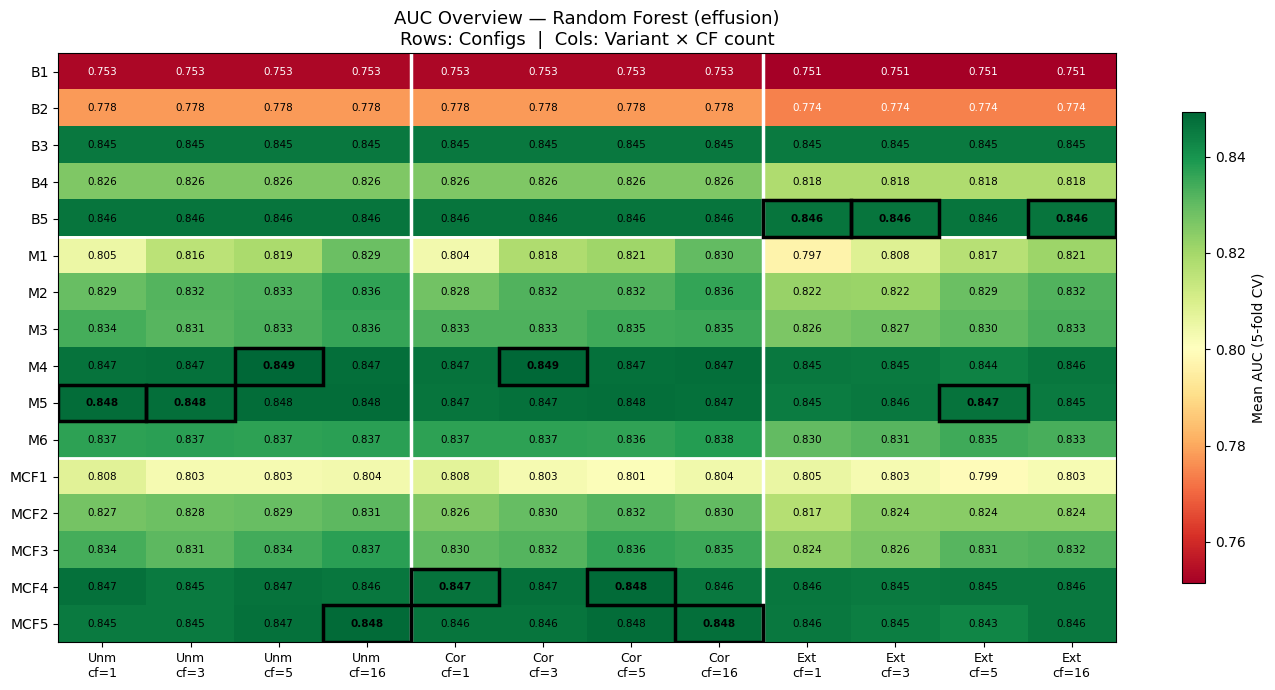

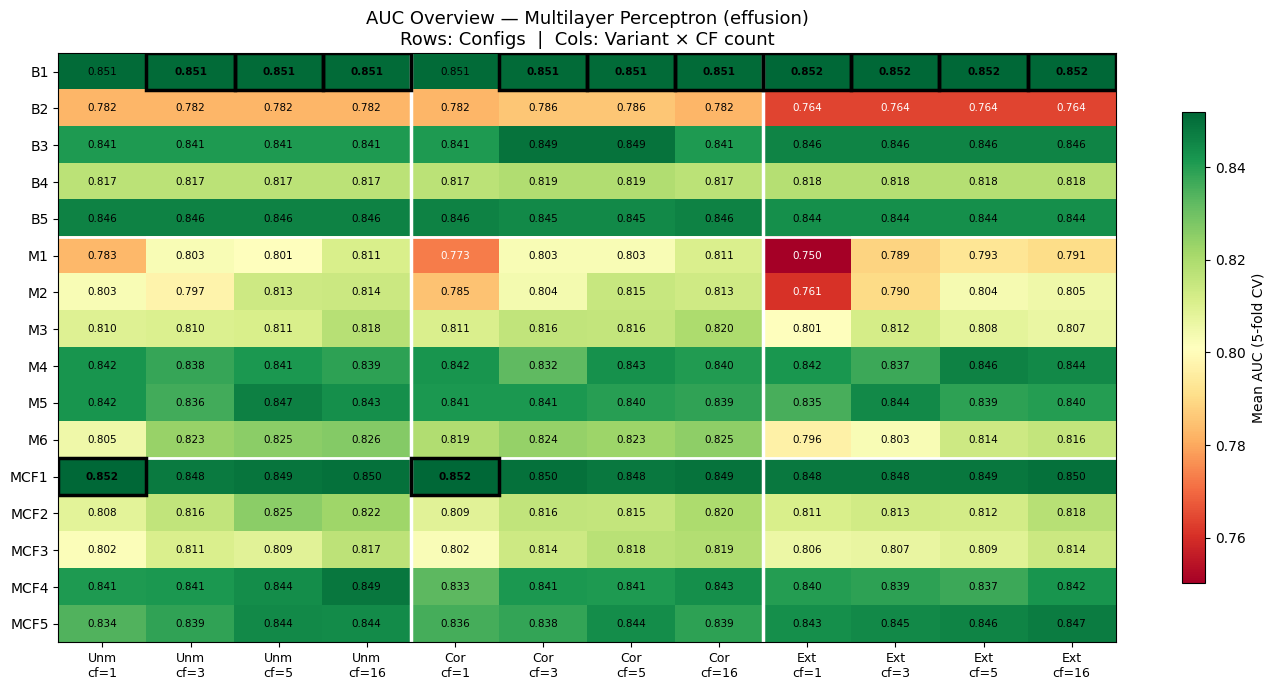

In [44]:
# ── AUC heatmap: full overview of all configs × variants × CF counts ──────────
ALL_CONFIGS = ['B1','B2','B3','B4','B5',
               'M1','M2','M3','M4','M5','M6',
               'MCF1','MCF2','MCF3','MCF4','MCF5']
VARIANT_LABELS_LIST = list(VARIANTS.keys())
SHORT_VARIANT = {
    'Unmatched':           'Unm',
    'Correct CF':          'Cor',
    'Extended Correct CF': 'Ext',
}
N_V = len(VARIANT_LABELS_LIST)
N_C = len(CF_COUNTS_COMPARE)

for model in MODELS_TO_PLOT:
    auc_matrix = np.full((len(ALL_CONFIGS), N_V * N_C), np.nan)
    col = 0
    for variant_label in VARIANT_LABELS_LIST:
        for cf in CF_COUNTS_COMPARE:
            data = all_data[variant_label][cf]
            for ri, config in enumerate(ALL_CONFIGS):
                if config in data.get(model, {}):
                    auc_matrix[ri, col] = load_roc(data, model, config)['auc']
            col += 1

    vmin, vmax = np.nanmin(auc_matrix), np.nanmax(auc_matrix)
    best_rows = np.nanargmax(auc_matrix, axis=0)  # best config index per column

    fig, ax = plt.subplots(figsize=(14, 7))
    im = ax.imshow(auc_matrix, aspect='auto', cmap='RdYlGn', vmin=vmin, vmax=vmax)

    for ri in range(len(ALL_CONFIGS)):
        for ci in range(N_V * N_C):
            val = auc_matrix[ri, ci]
            if not np.isnan(val):
                brightness = (val - vmin) / max(vmax - vmin, 1e-6)
                txt_color = 'white' if brightness < 0.25 else 'black'
                is_best = (ri == best_rows[ci])
                ax.text(ci, ri, f'{val:.3f}', ha='center', va='center',
                        fontsize=7.5, color=txt_color,
                        fontweight='bold' if is_best else 'normal')
                if is_best:
                    ax.add_patch(plt.Rectangle(
                        (ci - 0.5, ri - 0.5), 1, 1,
                        fill=False, edgecolor='black', lw=2.5, zorder=3
                    ))

    xtick_labels = [f'{SHORT_VARIANT[v]}\ncf={cf}'
                    for v in VARIANT_LABELS_LIST for cf in CF_COUNTS_COMPARE]
    ax.set_xticks(range(N_V * N_C))
    ax.set_xticklabels(xtick_labels, fontsize=9)
    ax.set_yticks(range(len(ALL_CONFIGS)))
    ax.set_yticklabels(ALL_CONFIGS, fontsize=10)

    # Horizontal separators between config groups (B / M / MCF)
    ax.axhline(4.5,  color='white', lw=2)
    ax.axhline(10.5, color='white', lw=2)

    # Vertical separators between variants
    for i in range(1, N_V):
        ax.axvline(i * N_C - 0.5, color='white', lw=2.5)

    plt.colorbar(im, ax=ax, shrink=0.8, label='Mean AUC (5-fold CV)')
    ax.set_title(f'AUC Overview — {MODEL_NAMES[model]} ({COMPARE_DISEASE})\n'
                 f'Rows: Configs  |  Cols: Variant × CF count', fontsize=13)
    plt.tight_layout()
    plt.show()

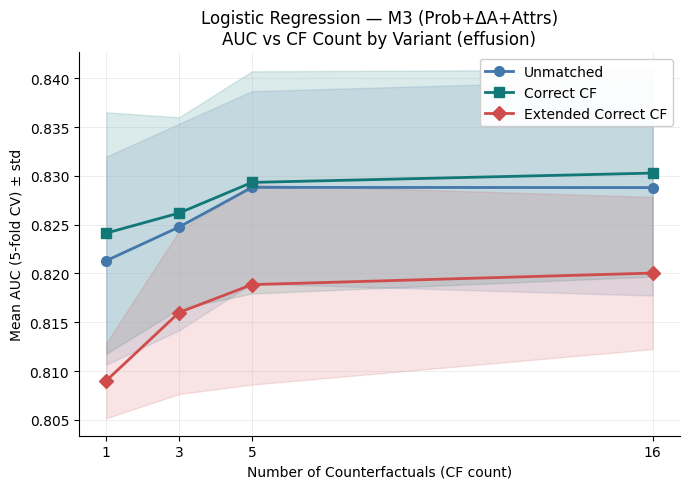

In [45]:
# ── Drill-down: AUC vs CF count for a chosen (model, config) ─────────────────
FOCUS_MODEL  = 'LR'   # LR | RF | MLP
FOCUS_CONFIG = 'M3'   # any config key, e.g. B5, M3, M6, MCF3

VARIANT_COLORS  = {
    'Unmatched':           '#4477AA',
    'Correct CF':          '#117777',
    'Extended Correct CF': '#D04B4B',
}
VARIANT_MARKERS = {
    'Unmatched':           'o',
    'Correct CF':          's',
    'Extended Correct CF': 'D',
}

fig, ax = plt.subplots(figsize=(7, 5))

for variant_label in VARIANT_LABELS_LIST:
    aucs_mean, aucs_std = [], []
    for cf in CF_COUNTS_COMPARE:
        roc = load_roc(all_data[variant_label][cf], FOCUS_MODEL, FOCUS_CONFIG)
        aucs_mean.append(roc['auc'])
        aucs_std.append(roc['auc_std'])
    aucs_mean = np.array(aucs_mean)
    aucs_std  = np.array(aucs_std)

    ax.plot(CF_COUNTS_COMPARE, aucs_mean,
            color=VARIANT_COLORS[variant_label],
            marker=VARIANT_MARKERS[variant_label],
            lw=2, ms=7, label=variant_label)
    ax.fill_between(CF_COUNTS_COMPARE, aucs_mean - aucs_std, aucs_mean + aucs_std,
                    color=VARIANT_COLORS[variant_label], alpha=0.15)

ax.set_xlabel('Number of Counterfactuals (CF count)')
ax.set_ylabel('Mean AUC (5-fold CV) ± std')
ax.set_title(f'{MODEL_NAMES[FOCUS_MODEL]} — {LABELS[FOCUS_CONFIG]}\n'
             f'AUC vs CF Count by Variant ({COMPARE_DISEASE})')
ax.set_xticks(CF_COUNTS_COMPARE)
ax.set_xticklabels([str(c) for c in CF_COUNTS_COMPARE])
ax.legend(framealpha=0.95, edgecolor='#cccccc')
ax.grid(alpha=0.3, linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 12. C0 Confidence Stratification — Does ΔA Help Where C0 is Uncertain?

B1 (Prob only) uses C0 probability as its sole input, so its `y_prob` is a monotonic proxy for C0 confidence.
We use it to define an uncertainty window `|p_B1 − 0.5| < threshold` and compare baseline vs ΔA configs
**only on those borderline samples**, sweeping from narrow (most uncertain) to full dataset.

C0 Youden threshold for effusion: 0.5634


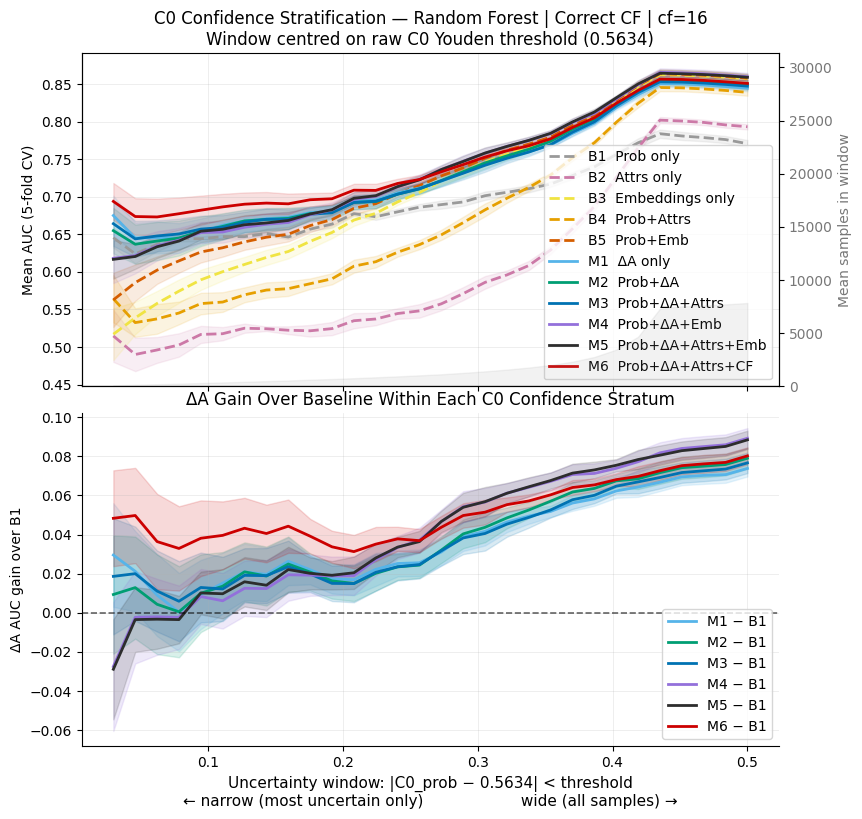


Config    Narrow (window=0.10)    Full dataset    Δ gain (narrow)
-----------------------------------------------------------------
B1                      0.6441          0.7530
B2                      0.5167          0.7780
B3                      0.5895          0.8454
B4                      0.5578          0.8257
B5                      0.6266          0.8464
M1                      0.6534          0.8300          +0.0094
M2                      0.6541          0.8362          +0.0100
M3                      0.6570          0.8347          +0.0129
M4                      0.6524          0.8474          +0.0083
M5                      0.6542          0.8472          +0.0101
M6                      0.6822          0.8379          +0.0381


In [56]:
from sklearn.metrics import roc_auc_score

# ── Config ─────────────────────────────────────────────────────────────────────
STRAT_MODEL   = 'RF'
STRAT_VARIANT = 'Correct CF'   # any key from VARIANTS
STRAT_CF      = 16

STRAT_BASELINES = ['B1', 'B2', 'B3', 'B4', 'B5']
STRAT_DELTA_A   = ['M1', 'M2', 'M3', 'M4', 'M5', 'M6']
STRAT_CONFIGS   = STRAT_BASELINES + STRAT_DELTA_A

# Youden-optimal C0 threshold
_thresh_path = f'/zhome/d0/a/221493/thesis/results/C0_custom/{COMPARE_DISEASE}/threshold.txt'
with open(_thresh_path) as _f:
    C0_THRESHOLD = float(_f.read().strip())
print(f"C0 Youden threshold for {COMPARE_DISEASE}: {C0_THRESHOLD:.4f}")

# Predictions CSVs hold the raw C0 prob per sample per fold
_variant_folder = VARIANTS[STRAT_VARIANT]
_pred_base = f'{BASE}/{_variant_folder}/cf_{STRAT_CF}'
_c0_col    = f'{COMPARE_DISEASE}_prob'   # e.g. 'effusion_prob'

thresholds = np.linspace(0.03, 0.50, 30)
data_strat = all_data[STRAT_VARIANT][STRAT_CF][STRAT_MODEL]

# Cache each fold's raw C0 probability once (was being re-read 30× per fold)
c0_prob_by_fold = {}
for fold_idx in range(5):
    pred_df = pd.read_csv(f'{_pred_base}/fold_{fold_idx}_predictions.csv',
                          usecols=[_c0_col])
    c0_prob_by_fold[fold_idx] = pred_df[_c0_col].values

auc_curves = {cfg: [] for cfg in STRAT_CONFIGS}
std_curves = {cfg: [] for cfg in STRAT_CONFIGS}
n_curve    = []

for thresh in thresholds:
    fold_aucs = {cfg: [] for cfg in STRAT_CONFIGS}
    fold_ns   = []

    for fold_idx in range(5):
        c0_prob = c0_prob_by_fold[fold_idx]          # cached, no disk read
        mask    = np.abs(c0_prob - C0_THRESHOLD) < thresh
        fold_ns.append(mask.sum())

        for cfg in STRAT_CONFIGS:
            y_prob = np.array(data_strat[cfg][fold_idx]['y_prob'])[mask]
            y_true = np.array(data_strat[cfg][fold_idx]['y_true'])[mask]
            if y_true.sum() > 5 and (y_true == 0).sum() > 5:
                fold_aucs[cfg].append(roc_auc_score(y_true, y_prob))

    for cfg in STRAT_CONFIGS:
        vals = fold_aucs[cfg]
        auc_curves[cfg].append(np.mean(vals) if vals else np.nan)
        std_curves[cfg].append(np.std(vals)  if vals else np.nan)
    n_curve.append(np.mean(fold_ns))

thresholds = np.array(thresholds)
n_curve    = np.array(n_curve)
se         = {cfg: np.array(std_curves[cfg]) / np.sqrt(5) for cfg in STRAT_CONFIGS}

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 9), sharex=True,
                                gridspec_kw={'hspace': 0.08})

# Top: absolute AUC
for cfg in STRAT_CONFIGS:
    aucs = np.array(auc_curves[cfg])
    ax1.plot(thresholds, aucs,
             color=COLORS[cfg], lw=2, ls=LINESTYLES[cfg],
             label=f"{cfg}  {LABELS[cfg].split('(')[1].rstrip(')')}")
    ax1.fill_between(thresholds, aucs - se[cfg], aucs + se[cfg],
                     color=COLORS[cfg], alpha=0.12)

ax1_r = ax1.twinx()
ax1_r.fill_between(thresholds, 0, n_curve, color='#999999', alpha=0.12)
ax1_r.set_ylabel('Mean samples in window', color='#777777', fontsize=10)
ax1_r.tick_params(axis='y', labelcolor='#777777')
ax1_r.set_ylim(0, n_curve.max() * 4)

ax1.set_ylabel('Mean AUC (5-fold CV)')
ax1.set_title(
    f'C0 Confidence Stratification — {MODEL_NAMES[STRAT_MODEL]} | {STRAT_VARIANT} | cf={STRAT_CF}\n'
    f'Window centred on raw C0 Youden threshold ({C0_THRESHOLD:.4f})',
    fontsize=12)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(alpha=0.3, linewidth=0.5)
ax1.spines['top'].set_visible(False)

# Bottom: ΔA gain over B4
ref = 'B1'
ref_aucs = np.array(auc_curves[ref])

for cfg in STRAT_DELTA_A:
    gain = np.array(auc_curves[cfg]) - ref_aucs
    ax2.plot(thresholds, gain,
             color=COLORS[cfg], lw=2, ls=LINESTYLES[cfg],
             label=f'{cfg} − {ref}')
    ax2.fill_between(thresholds, gain - se[cfg], gain + se[cfg],
                     color=COLORS[cfg], alpha=0.15)

ax2.axhline(0, color='black', lw=1.2, ls='--', alpha=0.6)
ax2.set_xlabel(
    f'Uncertainty window: |C0_prob − {C0_THRESHOLD:.4f}| < threshold\n'
    '← narrow (most uncertain only)                    wide (all samples) →',
    fontsize=11)
ax2.set_ylabel(f'ΔA AUC gain over {ref}')
ax2.set_title('ΔA Gain Over Baseline Within Each C0 Confidence Stratum', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3, linewidth=0.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.savefig(os.path.join(OUTPUT_DIR, f'stratified_delta_a_{STRAT_MODEL}_{STRAT_VARIANT}_cf{STRAT_CF}.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
narrow_idx = np.argmin(np.abs(thresholds - 0.10))

# True full-dataset AUC (no window) — not the widest window
full_auc = {}
for cfg in STRAT_CONFIGS:
    full_auc[cfg] = np.mean([roc_auc_score(np.array(data_strat[cfg][f]['y_true']),
                                            np.array(data_strat[cfg][f]['y_prob']))
                             for f in range(5)])

print(f"\n{'Config':<6}  {'Narrow (window=0.10)':>22}  {'Full dataset':>14}  {'Δ gain (narrow)':>17}")
print('-' * 65)
for cfg in STRAT_CONFIGS:
    aucs = np.array(auc_curves[cfg])
    gain_str = f"{aucs[narrow_idx] - ref_aucs[narrow_idx]:>+17.4f}" if cfg in STRAT_DELTA_A else ''
    print(f"{cfg:<6}  {aucs[narrow_idx]:>22.4f}  {full_auc[cfg]:>14.4f}{gain_str}")

## 13. Dual-CF Isolation — Does Splitting CFs by Correctness Help?

**Idea tested:** at training time, give each sample *two* counterfactuals — one from the
correct-neighbour pool (TN for a TP query, TP for a TN query) and one from the
incorrect-neighbour pool (FN / FP). The hypothesis is that presenting both a "right"
and "wrong" CF reference explicitly teaches the model to distinguish them at test time.

At **test time** routing uses predicted label only (no true-label leakage): the same
correct and incorrect sub-pools built from the training fold are queried independently.

Configs compared:
- `B4_single`: prob + attrs + CF-attrs (single mixed pool)
- `B4_dual`:   prob + attrs + CF-attrs-correct + CF-attrs-incorrect
- `M3_single`: prob + attrs + ΔA (single mixed pool)
- `M3_dual`:   prob + attrs + ΔA-correct + ΔA-incorrect

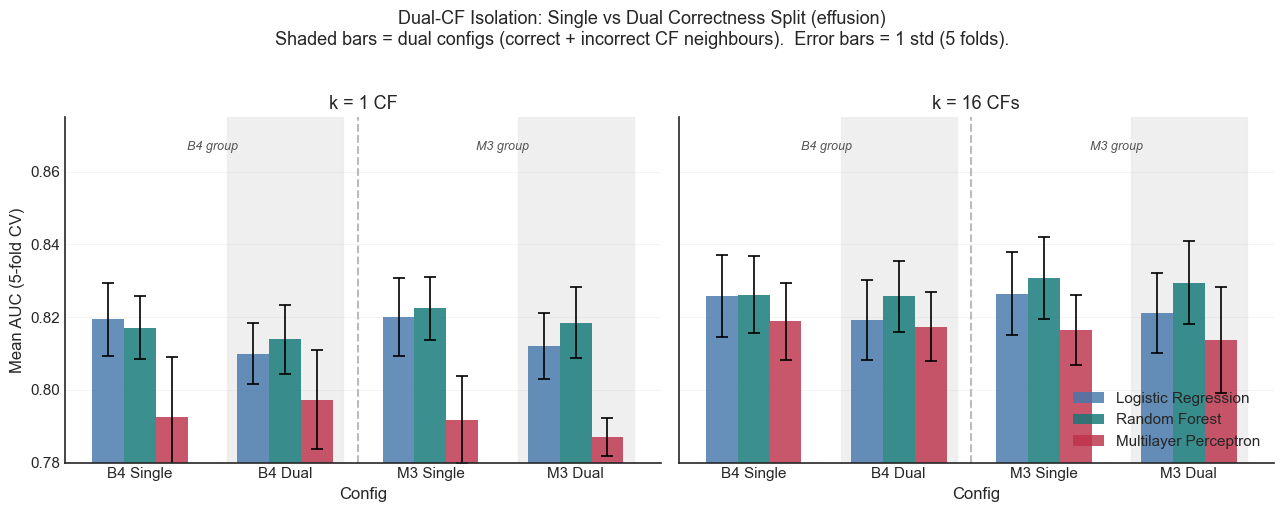


Paired comparison (dual − single)  |  effusion
──────────────────────────────────────────────────────────────────
Config pair            Model   Dual AUC  Single AUC    Δ AUC  Verdict
──────────────────────────────────────────────────────────────────
[k=1 ] B4_dual vs B4_single  LR        0.8099      0.8194  -0.0095  DUAL WORSE
[k=1 ] B4_dual vs B4_single  RF        0.8139      0.8171  -0.0032  NO DIFF
[k=1 ] B4_dual vs B4_single  MLP       0.7973      0.7926  +0.0047  NO DIFF
[k=1 ] M3_dual vs M3_single  LR        0.8120      0.8201  -0.0081  NO DIFF
[k=1 ] M3_dual vs M3_single  RF        0.8185      0.8224  -0.0039  NO DIFF
[k=1 ] M3_dual vs M3_single  MLP       0.7871      0.7918  -0.0047  NO DIFF
[k=16] B4_dual vs B4_single  LR        0.8192      0.8259  -0.0067  NO DIFF
[k=16] B4_dual vs B4_single  RF        0.8257      0.8262  -0.0005  NO DIFF
[k=16] B4_dual vs B4_single  MLP       0.8174      0.8188  -0.0014  NO DIFF
[k=16] M3_dual vs M3_single  LR        0.8211      0.8264  -0

In [11]:
# ── Load dual-CF isolation summary CSVs ───────────────────────────────────────
DUAL_CF_BASE = '/zhome/d0/a/221493/thesis/results/dual_cf_isolation/effusion'

df_k16 = pd.read_csv(f'{DUAL_CF_BASE}/summary_densenet_cf16.csv')
df_k1  = pd.read_csv(f'{DUAL_CF_BASE}/summary_densenet_cf1.csv')

MODELS_DUAL  = ['LR', 'RF', 'MLP']
DUAL_CONFIGS = ['B4_single', 'B4_dual', 'M3_single', 'M3_dual']

MODEL_COLORS  = {'LR': '#4477AA', 'RF': '#117777', 'MLP': '#BE324A'}
config_labels = ['B4 Single', 'B4 Dual', 'M3 Single', 'M3 Dual']
bar_width     = 0.22
x             = np.arange(len(DUAL_CONFIGS))

plt.style.use('seaborn-v0_8-white')
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 12,
    'axes.titlesize': 13, 'axes.labelsize': 12,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 1.2, 'grid.alpha': 0.3, 'grid.linewidth': 0.6,
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, df, k_label in [(axes[0], df_k1, 'k = 1 CF'), (axes[1], df_k16, 'k = 16 CFs')]:
    for mi, model in enumerate(MODELS_DUAL):
        mdf    = df[df['model'] == model].set_index('config')
        aucs   = [mdf.loc[c, 'mean_auc'] for c in DUAL_CONFIGS]
        stds   = [mdf.loc[c, 'std_auc']  for c in DUAL_CONFIGS]
        offset = (mi - 1) * bar_width
        ax.bar(x + offset, aucs, bar_width,
               yerr=stds, capsize=4,
               color=MODEL_COLORS[model], alpha=0.82,
               label=MODEL_NAMES[model], linewidth=0.8,
               error_kw=dict(lw=1.2, capthick=1.2))

    # Shade dual-config columns
    for xi in [1, 3]:
        ax.axvspan(xi - 0.4, xi + 0.4, color='#eeeeee', zorder=0, alpha=0.9)

    # Divider between B4 and M3 groups
    ax.axvline(1.5, color='#bbbbbb', lw=1.5, ls='--')

    # Group headers (in data coords: B4 centred at x=0.5, M3 at x=2.5)
    ymax = ax.get_ylim()[1] if ax.get_ylim()[1] > 0.80 else 0.87
    for gx, gtxt in [(0.5, 'B4 group'), (2.5, 'M3 group')]:
        ax.text(gx, 0.865, gtxt, ha='center', va='bottom', fontsize=9,
                color='#555555', style='italic')

    ax.set_xticks(x)
    ax.set_xticklabels(config_labels)
    ax.set_xlabel('Config')
    ax.set_title(f'{k_label}', fontsize=13)
    ax.grid(axis='y', alpha=0.3, linewidth=0.5)
    ax.set_ylim(0.78, 0.875)

axes[0].set_ylabel('Mean AUC (5-fold CV)')
axes[1].legend(loc='lower right', framealpha=0.95, edgecolor='#cccccc')

fig.suptitle(
    f'Dual-CF Isolation: Single vs Dual Correctness Split ({DISEASE})\n'
    'Shaded bars = dual configs (correct + incorrect CF neighbours).  Error bars = 1 std (5 folds).',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'dual_cf_isolation_{DISEASE}.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Conclusion table ───────────────────────────────────────────────────────────
print(f"\nPaired comparison (dual − single)  |  {DISEASE}")
print(f"{'─'*66}")
print(f"{'Config pair':<22} {'Model':<6} {'Dual AUC':>9} {'Single AUC':>11} {'Δ AUC':>8}  Verdict")
print(f"{'─'*66}")
for df_cmp, k_tag in [(df_k1, 'k=1 '), (df_k16, 'k=16')]:
    for dual_cfg, single_cfg in [('B4_dual', 'B4_single'), ('M3_dual', 'M3_single')]:
        for model in MODELS_DUAL:
            mdf   = df_cmp[df_cmp['model'] == model].set_index('config')
            d_m   = mdf.loc[dual_cfg,   'mean_auc']
            s_m   = mdf.loc[single_cfg, 'mean_auc']
            std   = mdf.loc[dual_cfg,   'std_auc']
            delta = d_m - s_m
            verdict = ('NO DIFF'    if abs(delta) <= std
                       else 'DUAL WINS' if delta > 0
                       else 'DUAL WORSE')
            print(f"[{k_tag}] {dual_cfg} vs {single_cfg:<10} {model:<6} "
                  f"{d_m:>9.4f} {s_m:>11.4f} {delta:>+8.4f}  {verdict}")